# Experiment: Threshold-Variety Cross-Method Grid

Objective:
- Compare SAMC, hard-step IS, and MCMC-IS without oracle p-values on the 50 GWAS-like and 50 HEP-like threshold scenarios.
- Use a 5M maximum reported budget with 250k checkpoints.
- Sweep swap size over 5% and 10% of the smaller group size.
- For MCMC-IS and hard-step, sweep `gamma in {0.25, 1/3, 0.4, 0.5}` with `q = p0 ** gamma`, where `p0` is the known application threshold stored in the scenario metadata.

Each family/swap/method/gamma block writes its own partial and final JSONL files as soon as it finishes.

In [1]:
from __future__ import annotations

from dataclasses import replace
import json
import os
import shutil
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "perm_pval").exists() and (candidate / "results").exists():
            return candidate
    raise RuntimeError("Could not locate project root containing perm_pval/ and results/.")


project_root = find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
os.environ.setdefault("MPLCONFIGDIR", str(project_root / ".matplotlib"))

from perm_pval.experiments.notebook_studies import (
    BetaSweepStudyConfig,
    CrossMethodStudyConfig,
    DEFAULT_MCMC_OBJECTIVE_GRID_Q_MULTIPLIERS,
    DEFAULT_MCMC_OBJECTIVE_GRID_SWAP_COUNTS,
    MCMCWorkflowConfig,
    MCMC_OBJECTIVE_GRID_REALISTIC_OBJECTIVES,
    SAMCWorkflowConfig,
    _mcmc_eval_count,
    _steps_per_chain,
    build_beta_initialization,
    build_beta_workflow,
    create_timestamped_run_dir,
    load_cross_method_saved_output,
    load_beta_sweep_saved_output,
    load_mcmc_objective_grid_saved_output,
    load_selected_scenarios,
    known_threshold_p0_for_scenario,
    plot_named_method_convergence,
    plot_named_method_max_budget,
    bootstrap_threshold_grid_best_practical_diagnostics,
    plot_threshold_grid_estimate_vs_threshold_ratio,
    plot_threshold_grid_best_practical_scenario_scatter,
    plot_threshold_grid_best_practical_rrmse,
    plot_threshold_grid_gamma_swap_rrmse,
    plot_threshold_grid_tilt_family_rrmse,
    read_json,
    run_named_mcmc_checkpoint_study,
    run_mcmc_objective_grid_study,
    run_threshold_grid_method_block,
    save_mcmc_objective_grid_outputs,
    regenerate_beta_sweep_plots_from_saved,
    regenerate_cross_method_plots_from_saved,
    run_beta_checkpoint_study,
    run_cross_method_study,
    save_beta_sweep_outputs,
    save_cross_method_outputs,
    summarize_threshold_grid_gamma_swap_rrmse,
    summarize_records,
    tune_samc_setup,
    write_json,
    write_jsonl,
    _effective_n_jobs,
    _iid_replicate_worker,
    _samc_replicate_worker,
    _try_make_process_pool,
)

pd.set_option("display.max_columns", 100)
project_root

PosixPath('/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS')

## Configuration

The default `THRESHOLD_BANDS = ("near",)` runs the 50-per-family near-threshold inventory. Set it to `("above",)` for the `[1.01, 1.25]` above-threshold inventory, or to both bands for the full threshold-variety catalog.

MCMC-IS uses the known threshold p0, not the exact scenario p-value, when setting `q` and initializing beta. Exact p-values are used only for error summaries.

In [2]:
FAST_MODE = False
SAVE_OUTPUTS = True
RESUME_BLOCKS = True
RUN_DIR_OVERRIDE = "/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method"  # Set to a previous run_dir string to resume after a kernel restart.
SKIP_IF_PRESENT = True

CATALOG_PATH = project_root / "results" / "exact_scenarios" / "v1" / "catalog.json"
OUTPUT_ROOT = project_root / "results" / "cross_method_threshold_grid"
LATEST_RESULTS_DIR = OUTPUT_ROOT / "20260724_160159_threshold_grid_cross_method"

THRESHOLD_BANDS = ("near",)
FAMILIES = ("gwas", "hep")
SCENARIOS_PER_FAMILY = 50
MIN_TAIL_STATES = 2

MAX_BUDGET = 5_000_000 if not FAST_MODE else 20_000
CHECKPOINT_STEP = 250_000 if not FAST_MODE else 5_000
CHECKPOINTS = tuple(range(CHECKPOINT_STEP, MAX_BUDGET + CHECKPOINT_STEP, CHECKPOINT_STEP))
APPENDIX_FIGURE_BUDGETS = (1_000_000, 2_500_000) if not FAST_MODE else tuple()
SWAP_FRACTIONS = (0.05, 0.10)
GAMMAS = (0.25, 1.0 / 3.0, 0.40, 0.50)

BETA_INIT_PILOT_SAMPLES = 100_000 if not FAST_MODE else 1_000
N_JOBS = min(6, os.cpu_count() or 1) if not FAST_MODE else 1
BASE_SEED = 91_337
BOOTSTRAP_RESAMPLES = 10_000 if not FAST_MODE else 1_000
BOOTSTRAP_SEED = BASE_SEED + 30_000

MCMC_CHAINS = 1
MCMC_ESTIMATE_VARIANCE = False
MCMC_CFG = MCMCWorkflowConfig(
    use_true_p0_for_q_target=False,
    p0_guess=1e-8,
    pilot_samples=BETA_INIT_PILOT_SAMPLES,
    scale_method="sd",
    beta_max_init=1e6,
    chains=MCMC_CHAINS,
    thin=1,
    estimate_variance=MCMC_ESTIMATE_VARIANCE,
    chain_n_jobs=1,
    production_estimator_variant="production_only",
    tilt_mode="smooth_hinge",
    proposal_size=SWAP_FRACTIONS[0],
    local_scan_enabled=False,
)
SAMC_CFG = SAMCWorkflowConfig(
    burn_in_fraction=0.20,
    n_bins=100 if not FAST_MODE else 10,
    t0=1_000.0,
    trace_every=200 if not FAST_MODE else 50,
    convergence_tolerance=20.0,
    lambda_min_pilot=10_000 if not FAST_MODE else 1_000,
    proposal_size=SWAP_FRACTIONS[0],
)

print(json.dumps({
    "FAST_MODE": FAST_MODE,
    "THRESHOLD_BANDS": THRESHOLD_BANDS,
    "FAMILIES": FAMILIES,
    "SCENARIOS_PER_FAMILY": SCENARIOS_PER_FAMILY,
    "MAX_BUDGET": MAX_BUDGET,
    "CHECKPOINT_STEP": CHECKPOINT_STEP,
    "N_CHECKPOINTS": len(CHECKPOINTS),
    "APPENDIX_FIGURE_BUDGETS": APPENDIX_FIGURE_BUDGETS,
    "SWAP_FRACTIONS": SWAP_FRACTIONS,
    "GAMMAS": GAMMAS,
    "BETA_INIT_PILOT_SAMPLES": BETA_INIT_PILOT_SAMPLES,
    "BOOTSTRAP_RESAMPLES": BOOTSTRAP_RESAMPLES,
    "BOOTSTRAP_SEED": BOOTSTRAP_SEED,
    "MCMC_CHAINS": MCMC_CHAINS,
    "MCMC_ESTIMATE_VARIANCE": MCMC_ESTIMATE_VARIANCE,
    "SAMC_N_BINS": SAMC_CFG.n_bins,
    "SAMC_LAMBDA_MIN_PILOT": SAMC_CFG.lambda_min_pilot,
    "N_JOBS": N_JOBS,
    "SAVE_OUTPUTS": SAVE_OUTPUTS,
    "RESUME_BLOCKS": RESUME_BLOCKS,
    "SKIP_IF_PRESENT": SKIP_IF_PRESENT,
    "LATEST_RESULTS_DIR": str(LATEST_RESULTS_DIR) if LATEST_RESULTS_DIR is not None else None,
}, indent=2))

{
  "FAST_MODE": false,
  "THRESHOLD_BANDS": [
    "near"
  ],
  "FAMILIES": [
    "gwas",
    "hep"
  ],
  "SCENARIOS_PER_FAMILY": 50,
  "MAX_BUDGET": 5000000,
  "CHECKPOINT_STEP": 250000,
  "N_CHECKPOINTS": 20,
  "APPENDIX_FIGURE_BUDGETS": [
    1000000,
    2500000
  ],
  "SWAP_FRACTIONS": [
    0.05,
    0.1
  ],
  "GAMMAS": [
    0.25,
    0.3333333333333333,
    0.4,
    0.5
  ],
  "BETA_INIT_PILOT_SAMPLES": 100000,
  "BOOTSTRAP_RESAMPLES": 10000,
  "BOOTSTRAP_SEED": 121337,
  "MCMC_CHAINS": 1,
  "MCMC_ESTIMATE_VARIANCE": false,
  "SAMC_N_BINS": 100,
  "SAMC_LAMBDA_MIN_PILOT": 10000,
  "N_JOBS": 6,
  "SAVE_OUTPUTS": true,
  "RESUME_BLOCKS": true,
  "SKIP_IF_PRESENT": true,
  "LATEST_RESULTS_DIR": "/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method"
}


## Load Scenario Inventory

In [3]:
def scenario_keys_for_family(family: str, threshold_band: str, n: int) -> list[str]:
    if family == "gwas":
        return [
            f"gwas_additive_score_{threshold_band}_v{idx:02d}_n120"
            for idx in range(1, int(n) + 1)
        ]
    if family == "hep":
        return [
            f"poisson_diffmeans_hep_{threshold_band}_v{idx:02d}_n200"
            for idx in range(1, int(n) + 1)
        ]
    raise ValueError(f"Unknown family: {family}")


def family_from_key(key: str) -> str:
    if key.startswith("gwas_additive_score_"):
        return "gwas"
    if key.startswith("poisson_diffmeans_hep_"):
        return "hep"
    raise ValueError(f"Could not infer family from key: {key}")


def threshold_band_from_key(key: str) -> str:
    if "_near_" in key:
        return "near"
    if "_above_" in key:
        return "above"
    raise ValueError(f"Could not infer threshold band from key: {key}")


scenario_keys = [
    key
    for threshold_band in THRESHOLD_BANDS
    for family in FAMILIES
    for key in scenario_keys_for_family(family, threshold_band, SCENARIOS_PER_FAMILY)
]
scenarios = load_selected_scenarios(
    catalog_path=CATALOG_PATH,
    scenario_keys=scenario_keys,
    portfolio_group=None,
    min_tail_states=MIN_TAIL_STATES,
)
scenarios_by_block = {
    (threshold_band, family): [
        scenario
        for scenario in scenarios
        if threshold_band_from_key(scenario.key) == threshold_band
        and family_from_key(scenario.key) == family
    ]
    for threshold_band in THRESHOLD_BANDS
    for family in FAMILIES
}

inventory_rows = []
for scenario in scenarios:
    p0, p0_source = known_threshold_p0_for_scenario(scenario)
    inventory_rows.append({
        "threshold_band": threshold_band_from_key(scenario.key),
        "family": family_from_key(scenario.key),
        "scenario": scenario.key,
        "n": scenario.problem.n,
        "n_treated": scenario.problem.n_treated,
        "n_control": scenario.problem.n_control,
        "exact_p": scenario.exact_p,
        "p0": p0,
        "p0_source": p0_source,
        "p_over_p0": scenario.exact_p / p0,
        "tail_hits": scenario.exact_tail_hits,
        "n_perm": scenario.exact_n_perm,
    })
inventory_df = pd.DataFrame(inventory_rows)
display(
    inventory_df
    .groupby(["threshold_band", "family"])
    .agg(
        n_scenarios=("scenario", "count"),
        min_p_over_p0=("p_over_p0", "min"),
        median_p_over_p0=("p_over_p0", "median"),
        max_p_over_p0=("p_over_p0", "max"),
        p0=("p0", "first"),
    )
    .reset_index()
)
inventory_df.head()

,threshold_band,family,n_scenarios,min_p_over_p0,median_p_over_p0,max_p_over_p0,p0
0,near,gwas,50,0.753736,0.856662,0.972833,5.000000e-08
1,near,hep,50,0.758070,0.862960,0.982994,3.000000e-07


,threshold_band,family,scenario,n,n_treated,n_control,exact_p,p0,p0_source,p_over_p0,tail_hits,n_perm
0,near,gwas,gwas_additive_score_near_v01_n120,120,60,60,3.894307e-08,5.000000e-08,scenario_extra_known_significance_threshold,0.778861,3762481262021530689834460860,96614908840363322603893139521372656
1,near,gwas,gwas_additive_score_near_v02_n120,120,60,60,4.829081e-08,5.000000e-08,scenario_extra_known_significance_threshold,0.965816,4665612159913993200960281976,96614908840363322603893139521372656
2,near,gwas,gwas_additive_score_near_v03_n120,120,60,60,4.571380e-08,5.000000e-08,scenario_extra_known_significance_threshold,0.914276,4416634395266742474284204124,96614908840363322603893139521372656
3,near,gwas,gwas_additive_score_near_v04_n120,120,60,60,4.637464e-08,5.000000e-08,scenario_extra_known_significance_threshold,0.927493,4480481431009059526199880780,96614908840363322603893139521372656
4,near,gwas,gwas_additive_score_near_v05_n120,120,60,60,3.772819e-08,5.000000e-08,scenario_extra_known_significance_threshold,0.754564,3645106059048243748849041816,96614908840363322603893139521372656


## Build Method Blocks

In [4]:
def gamma_label(gamma: float | None) -> str:
    return "none" if gamma is None else f"{float(gamma):.12g}".replace(".", "p")


def swap_label(swap_fraction: float | int) -> str:
    if isinstance(swap_fraction, float):
        return f"{int(round(100 * swap_fraction)):02d}pct"
    return f"{int(swap_fraction)}swap"


def block_slug(block: dict) -> str:
    parts = [
        f"band_{block['threshold_band']}",
        f"family_{block['family']}",
        f"swap_{swap_label(block['swap_fraction'])}",
        f"method_{block['method']}",
    ]
    if block.get("gamma") is not None:
        parts.append(f"gamma_{gamma_label(block['gamma'])}")
    return "__".join(parts)


method_blocks = []
for threshold_band in THRESHOLD_BANDS:
    for family in FAMILIES:
        block_scenarios = scenarios_by_block[(threshold_band, family)]
        if len(block_scenarios) != SCENARIOS_PER_FAMILY:
            raise RuntimeError(
                f"Expected {SCENARIOS_PER_FAMILY} scenarios for {(threshold_band, family)}, "
                f"found {len(block_scenarios)}."
            )
        for swap_fraction in SWAP_FRACTIONS:
            method_blocks.append({
                "method": "samc",
                "threshold_band": threshold_band,
                "family": family,
                "swap_fraction": float(swap_fraction),
                "gamma": None,
                "scenarios": block_scenarios,
            })
            for gamma in GAMMAS:
                method_blocks.append({
                    "method": "mcmc_is",
                    "threshold_band": threshold_band,
                    "family": family,
                    "swap_fraction": float(swap_fraction),
                    "gamma": float(gamma),
                    "scenarios": block_scenarios,
                })
                method_blocks.append({
                    "method": "hard_step",
                    "threshold_band": threshold_band,
                    "family": family,
                    "swap_fraction": float(swap_fraction),
                    "gamma": float(gamma),
                    "scenarios": block_scenarios,
                })

block_plan = pd.DataFrame([
    {
        "block_index": idx,
        "block_slug": block_slug(block),
        "threshold_band": block["threshold_band"],
        "family": block["family"],
        "method": block["method"],
        "swap_fraction": block["swap_fraction"],
        "gamma": block["gamma"],
        "n_scenarios": len(block["scenarios"]),
    }
    for idx, block in enumerate(method_blocks)
])
display(block_plan)
print(f"{len(block_plan)} method blocks; each block saves independently.")

,block_index,block_slug,threshold_band,family,method,swap_fraction,gamma,n_scenarios
0,0,band_near__family_gwas__swap_05pct__method_samc,near,gwas,samc,0.05,NaN,50
1,1,band_near__family_gwas__swap_05pct__method_mcm...,near,gwas,mcmc_is,0.05,0.250000,50
2,2,band_near__family_gwas__swap_05pct__method_har...,near,gwas,hard_step,0.05,0.250000,50
3,3,band_near__family_gwas__swap_05pct__method_mcm...,near,gwas,mcmc_is,0.05,0.333333,50
4,4,band_near__family_gwas__swap_05pct__method_har...,near,gwas,hard_step,0.05,0.333333,50
5,5,band_near__family_gwas__swap_05pct__method_mcm...,near,gwas,mcmc_is,0.05,0.400000,50
6,6,band_near__family_gwas__swap_05pct__method_har...,near,gwas,hard_step,0.05,0.400000,50
7,7,band_near__family_gwas__swap_05pct__method_mcm...,near,gwas,mcmc_is,0.05,0.500000,50
8,8,band_near__family_gwas__swap_05pct__method_har...,near,gwas,hard_step,0.05,0.500000,50
9,9,band_near__family_gwas__swap_10pct__method_samc,near,gwas,samc,0.10,NaN,50


36 method blocks; each block saves independently.


## Run Blocks

In [5]:
def resolve_latest_results_dir() -> Path | None:
    if not bool(SKIP_IF_PRESENT):
        return None
    if LATEST_RESULTS_DIR is None:
        raise ValueError("SKIP_IF_PRESENT=True requires LATEST_RESULTS_DIR to be set.")
    latest = Path(LATEST_RESULTS_DIR).expanduser()
    if not latest.is_absolute():
        latest = (project_root / latest).resolve()
    else:
        latest = latest.resolve()
    if not latest.exists():
        raise FileNotFoundError(f"LATEST_RESULTS_DIR does not exist: {latest}")
    return latest


latest_results_dir = resolve_latest_results_dir()


def _same_optional_float(left, right) -> bool:
    if left is None and right is None:
        return True
    if left is None or right is None:
        return False
    return abs(float(left) - float(right)) <= 1e-12


def prior_block_is_compatible(prior_block_dir: Path, block: dict) -> bool:
    records_path = prior_block_dir / "block_records.jsonl"
    if not records_path.exists():
        return False
    metadata_path = prior_block_dir / "block_metadata.json"
    if metadata_path.exists():
        metadata = read_json(metadata_path)
        if str(metadata.get("method")) != str(block["method"]):
            return False
        if str(metadata.get("family")) != str(block["family"]):
            return False
        if str(metadata.get("threshold_band")) != str(block["threshold_band"]):
            return False
        if not _same_optional_float(metadata.get("swap_fraction"), block["swap_fraction"]):
            return False
        if not _same_optional_float(metadata.get("gamma"), block["gamma"]):
            return False
        if int(metadata.get("max_budget", -1)) != int(MAX_BUDGET):
            return False
        if tuple(int(x) for x in metadata.get("checkpoints", [])) != tuple(int(x) for x in CHECKPOINTS):
            return False
    records = pd.read_json(records_path, orient="records", lines=True)
    expected_scenarios = {scenario.key for scenario in block["scenarios"]}
    if set(records["scenario"].dropna().astype(str)) != expected_scenarios:
        return False
    if int(records["checkpoint"].max()) != int(MAX_BUDGET):
        return False
    return True


def copy_prior_block_if_present(block: dict, slug: str, block_dir: Path | None) -> Path | None:
    if latest_results_dir is None:
        return None
    prior_block_dir = latest_results_dir / slug
    if not prior_block_is_compatible(prior_block_dir, block):
        return None
    if block_dir is not None and block_dir.resolve() != prior_block_dir.resolve():
        block_dir.mkdir(parents=True, exist_ok=True)
        for filename in ("block_records.jsonl", "block_summary.json", "block_metadata.json"):
            source = prior_block_dir / filename
            if source.exists():
                shutil.copy2(source, block_dir / filename)
    return prior_block_dir


if SAVE_OUTPUTS:
    if RUN_DIR_OVERRIDE is not None:
        run_dir = Path(RUN_DIR_OVERRIDE).expanduser().resolve()
        run_dir.mkdir(parents=True, exist_ok=True)
    else:
        run_dir = create_timestamped_run_dir(OUTPUT_ROOT, "threshold_grid_cross_method")
else:
    run_dir = None

block_results = []
for block_index, block in enumerate(method_blocks):
    slug = block_slug(block)
    block_dir = (run_dir / slug) if run_dir is not None else None
    reused_from_prior = copy_prior_block_if_present(block, slug, block_dir)
    print(json.dumps({
        "block": f"{block_index + 1}/{len(method_blocks)}",
        "slug": slug,
        "method": block["method"],
        "threshold_band": block["threshold_band"],
        "family": block["family"],
        "swap_fraction": block["swap_fraction"],
        "gamma": block["gamma"],
        "n_scenarios": len(block["scenarios"]),
        "output_dir": str(block_dir) if block_dir is not None else None,
        "reused_from_prior": str(reused_from_prior) if reused_from_prior is not None else None,
    }, indent=2))
    result = run_threshold_grid_method_block(
        block["scenarios"],
        method=block["method"],
        family=block["family"],
        threshold_band=block["threshold_band"],
        checkpoints=CHECKPOINTS,
        swap_fraction=block["swap_fraction"],
        gamma=block["gamma"],
        mcmc_cfg=MCMC_CFG,
        samc_cfg=SAMC_CFG,
        base_seed=BASE_SEED + 1_000_000 * block_index,
        n_jobs=N_JOBS,
        output_dir=block_dir,
        resume=RESUME_BLOCKS,
        block_label=slug,
    )
    block_results.append({
        "block_index": block_index,
        "block_slug": slug,
        "threshold_band": block["threshold_band"],
        "family": block["family"],
        "method": block["method"],
        "swap_fraction": block["swap_fraction"],
        "gamma": block["gamma"],
        "n_records": len(result["records"]),
        "n_summary_rows": len(result["summary"]),
        "output_dir": str(result["output_dir"]) if result["output_dir"] is not None else None,
        "loaded_from": str(result["loaded_from"]) if result.get("loaded_from") is not None else None,
        "reused_from_prior": str(reused_from_prior) if reused_from_prior is not None else None,
        "wall_time_sec": result["metadata"].get("wall_time_sec"),
        "status": result["metadata"].get("status"),
        "result": result,
    })

block_manifest = pd.DataFrame([
    {key: value for key, value in item.items() if key != "result"}
    for item in block_results
])
display(block_manifest)
run_dir

{
  "block": "1/36",
  "slug": "band_near__family_gwas__swap_05pct__method_samc",
  "method": "samc",
  "threshold_band": "near",
  "family": "gwas",
  "swap_fraction": 0.05,
  "gamma": null,
  "n_scenarios": 50,
  "output_dir": "/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/band_near__family_gwas__swap_05pct__method_samc",
  "reused_from_prior": "/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/band_near__family_gwas__swap_05pct__method_samc"
}
{
  "block": "2/36",
  "slug": "band_near__family_gwas__swap_05pct__method_mcmc_is__gamma_0p25",
  "method": "mcmc_is",
  "threshold_band": "near",
  "family": "gwas",
  "swap_fraction": 0.05,
  "gamma": 0.25,
  "n_scenarios": 50,
  "output_dir": "/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshol

{
  "block": "4/36",
  "slug": "band_near__family_gwas__swap_05pct__method_mcmc_is__gamma_0p333333333333",
  "method": "mcmc_is",
  "threshold_band": "near",
  "family": "gwas",
  "swap_fraction": 0.05,
  "gamma": 0.3333333333333333,
  "n_scenarios": 50,
  "output_dir": "/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/band_near__family_gwas__swap_05pct__method_mcmc_is__gamma_0p333333333333",
  "reused_from_prior": "/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/band_near__family_gwas__swap_05pct__method_mcmc_is__gamma_0p333333333333"
}
{
  "block": "5/36",
  "slug": "band_near__family_gwas__swap_05pct__method_hard_step__gamma_0p333333333333",
  "method": "hard_step",
  "threshold_band": "near",
  "family": "gwas",
  "swap_fraction": 0.05,
  "gamma": 0.3333333333333333,
  "n_scenarios": 50,
  "output_dir": 

{
  "block": "7/36",
  "slug": "band_near__family_gwas__swap_05pct__method_hard_step__gamma_0p4",
  "method": "hard_step",
  "threshold_band": "near",
  "family": "gwas",
  "swap_fraction": 0.05,
  "gamma": 0.4,
  "n_scenarios": 50,
  "output_dir": "/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/band_near__family_gwas__swap_05pct__method_hard_step__gamma_0p4",
  "reused_from_prior": "/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/band_near__family_gwas__swap_05pct__method_hard_step__gamma_0p4"
}
{
  "block": "8/36",
  "slug": "band_near__family_gwas__swap_05pct__method_mcmc_is__gamma_0p5",
  "method": "mcmc_is",
  "threshold_band": "near",
  "family": "gwas",
  "swap_fraction": 0.05,
  "gamma": 0.5,
  "n_scenarios": 50,
  "output_dir": "/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cr

{
  "block": "10/36",
  "slug": "band_near__family_gwas__swap_10pct__method_samc",
  "method": "samc",
  "threshold_band": "near",
  "family": "gwas",
  "swap_fraction": 0.1,
  "gamma": null,
  "n_scenarios": 50,
  "output_dir": "/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/band_near__family_gwas__swap_10pct__method_samc",
  "reused_from_prior": "/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/band_near__family_gwas__swap_10pct__method_samc"
}
{
  "block": "11/36",
  "slug": "band_near__family_gwas__swap_10pct__method_mcmc_is__gamma_0p25",
  "method": "mcmc_is",
  "threshold_band": "near",
  "family": "gwas",
  "swap_fraction": 0.1,
  "gamma": 0.25,
  "n_scenarios": 50,
  "output_dir": "/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshol

{
  "block": "13/36",
  "slug": "band_near__family_gwas__swap_10pct__method_mcmc_is__gamma_0p333333333333",
  "method": "mcmc_is",
  "threshold_band": "near",
  "family": "gwas",
  "swap_fraction": 0.1,
  "gamma": 0.3333333333333333,
  "n_scenarios": 50,
  "output_dir": "/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/band_near__family_gwas__swap_10pct__method_mcmc_is__gamma_0p333333333333",
  "reused_from_prior": "/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/band_near__family_gwas__swap_10pct__method_mcmc_is__gamma_0p333333333333"
}
{
  "block": "14/36",
  "slug": "band_near__family_gwas__swap_10pct__method_hard_step__gamma_0p333333333333",
  "method": "hard_step",
  "threshold_band": "near",
  "family": "gwas",
  "swap_fraction": 0.1,
  "gamma": 0.3333333333333333,
  "n_scenarios": 50,
  "output_dir": 

...

{
  "block": "32/36",
  "slug": "band_near__family_hep__swap_10pct__method_hard_step__gamma_0p333333333333",
  "method": "hard_step",
  "threshold_band": "near",
  "family": "hep",
  "swap_fraction": 0.1,
  "gamma": 0.3333333333333333,
  "n_scenarios": 50,
  "output_dir": "/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/band_near__family_hep__swap_10pct__method_hard_step__gamma_0p333333333333",
  "reused_from_prior": "/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/band_near__family_hep__swap_10pct__method_hard_step__gamma_0p333333333333"
}


{
  "block": "33/36",
  "slug": "band_near__family_hep__swap_10pct__method_mcmc_is__gamma_0p4",
  "method": "mcmc_is",
  "threshold_band": "near",
  "family": "hep",
  "swap_fraction": 0.1,
  "gamma": 0.4,
  "n_scenarios": 50,
  "output_dir": "/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/band_near__family_hep__swap_10pct__method_mcmc_is__gamma_0p4",
  "reused_from_prior": "/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/band_near__family_hep__swap_10pct__method_mcmc_is__gamma_0p4"
}
{
  "block": "34/36",
  "slug": "band_near__family_hep__swap_10pct__method_hard_step__gamma_0p4",
  "method": "hard_step",
  "threshold_band": "near",
  "family": "hep",
  "swap_fraction": 0.1,
  "gamma": 0.4,
  "n_scenarios": 50,
  "output_dir": "/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method

{
  "block": "36/36",
  "slug": "band_near__family_hep__swap_10pct__method_hard_step__gamma_0p5",
  "method": "hard_step",
  "threshold_band": "near",
  "family": "hep",
  "swap_fraction": 0.1,
  "gamma": 0.5,
  "n_scenarios": 50,
  "output_dir": "/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/band_near__family_hep__swap_10pct__method_hard_step__gamma_0p5",
  "reused_from_prior": "/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/band_near__family_hep__swap_10pct__method_hard_step__gamma_0p5"
}


,block_index,block_slug,threshold_band,family,method,swap_fraction,gamma,n_records,n_summary_rows,output_dir,loaded_from,reused_from_prior,wall_time_sec,status
0,0,band_near__family_gwas__swap_05pct__method_samc,near,gwas,samc,0.05,NaN,1000,20,/Users/noamchowers/Documents/University/Thesis...,/Users/noamchowers/Documents/University/Thesis...,/Users/noamchowers/Documents/University/Thesis...,1785.732415,loaded_complete
1,1,band_near__family_gwas__swap_05pct__method_mcm...,near,gwas,mcmc_is,0.05,0.250000,1000,20,/Users/noamchowers/Documents/University/Thesis...,/Users/noamchowers/Documents/University/Thesis...,/Users/noamchowers/Documents/University/Thesis...,1259.979061,loaded_complete
2,2,band_near__family_gwas__swap_05pct__method_har...,near,gwas,hard_step,0.05,0.250000,1000,20,/Users/noamchowers/Documents/University/Thesis...,/Users/noamchowers/Documents/University/Thesis...,/Users/noamchowers/Documents/University/Thesis...,1237.603899,loaded_complete
3,3,band_near__family_gwas__swap_05pct__method_mcm...,near,gwas,mcmc_is,0.05,0.333333,1000,20,/Users/noamchowers/Documents/University/Thesis...,/Users/noamchowers/Documents/University/Thesis...,/Users/noamchowers/Documents/University/Thesis...,1269.394737,loaded_complete
4,4,band_near__family_gwas__swap_05pct__method_har...,near,gwas,hard_step,0.05,0.333333,1000,20,/Users/noamchowers/Documents/University/Thesis...,/Users/noamchowers/Documents/University/Thesis...,/Users/noamchowers/Documents/University/Thesis...,1261.842361,loaded_complete
5,5,band_near__family_gwas__swap_05pct__method_mcm...,near,gwas,mcmc_is,0.05,0.400000,1000,20,/Users/noamchowers/Documents/University/Thesis...,/Users/noamchowers/Documents/University/Thesis...,/Users/noamchowers/Documents/University/Thesis...,1290.234340,loaded_complete
6,6,band_near__family_gwas__swap_05pct__method_har...,near,gwas,hard_step,0.05,0.400000,1000,20,/Users/noamchowers/Documents/University/Thesis...,/Users/noamchowers/Documents/University/Thesis...,/Users/noamchowers/Documents/University/Thesis...,1195.876653,loaded_complete
7,7,band_near__family_gwas__swap_05pct__method_mcm...,near,gwas,mcmc_is,0.05,0.500000,1000,20,/Users/noamchowers/Documents/University/Thesis...,/Users/noamchowers/Documents/University/Thesis...,/Users/noamchowers/Documents/University/Thesis...,1265.837174,loaded_complete
8,8,band_near__family_gwas__swap_05pct__method_har...,near,gwas,hard_step,0.05,0.500000,1000,20,/Users/noamchowers/Documents/University/Thesis...,/Users/noamchowers/Documents/University/Thesis...,/Users/noamchowers/Documents/University/Thesis...,1339.431957,loaded_complete
9,9,band_near__family_gwas__swap_10pct__method_samc,near,gwas,samc,0.10,NaN,1000,20,/Users/noamchowers/Documents/University/Thesis...,/Users/noamchowers/Documents/University/Thesis...,/Users/noamchowers/Documents/University/Thesis...,1738.632772,loaded_complete


PosixPath('/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method')

## Aggregate And Save

In [6]:
all_records = [
    row
    for block_result in block_results
    for row in block_result["result"]["records"]
]
all_summary = summarize_records(
    all_records,
    group_fields=("threshold_band", "family", "swap_fraction", "method", "gamma_label", "checkpoint"),
)
records_df = pd.DataFrame(all_records)
summary_df = pd.DataFrame(all_summary)

if SAVE_OUTPUTS and run_dir is not None:
    records_df.to_json(run_dir / "all_records.jsonl", orient="records", lines=True)
    summary_df.to_json(run_dir / "summary.json", orient="records", indent=2)
    block_manifest.to_json(run_dir / "block_manifest.json", orient="records", indent=2)
    inventory_df.to_json(run_dir / "scenario_inventory.json", orient="records", indent=2)
    (run_dir / "config.json").write_text(
        json.dumps(
            {
                "CATALOG_PATH": str(CATALOG_PATH),
                "THRESHOLD_BANDS": THRESHOLD_BANDS,
                "FAMILIES": FAMILIES,
                "SCENARIOS_PER_FAMILY": SCENARIOS_PER_FAMILY,
                "MAX_BUDGET": MAX_BUDGET,
                "CHECKPOINT_STEP": CHECKPOINT_STEP,
                "CHECKPOINTS": CHECKPOINTS,
                "SWAP_FRACTIONS": SWAP_FRACTIONS,
                "GAMMAS": GAMMAS,
                "BETA_INIT_PILOT_SAMPLES": BETA_INIT_PILOT_SAMPLES,
                "N_JOBS": N_JOBS,
                "BASE_SEED": BASE_SEED,
                "MCMC_CHAINS": MCMC_CHAINS,
                "MCMC_ESTIMATE_VARIANCE": MCMC_ESTIMATE_VARIANCE,
                "SAMC_N_BINS": SAMC_CFG.n_bins,
                "SAMC_LAMBDA_MIN_PILOT": SAMC_CFG.lambda_min_pilot,
                "RESUME_BLOCKS": RESUME_BLOCKS,
                "SKIP_IF_PRESENT": SKIP_IF_PRESENT,
                "LATEST_RESULTS_DIR": str(latest_results_dir) if latest_results_dir is not None else None,
            },
            indent=2,
        ),
        encoding="utf-8",
    )
    print(f"Saved aggregate outputs to {run_dir}")

display(
    summary_df
    .query("checkpoint == @MAX_BUDGET")
    .sort_values(["threshold_band", "family", "swap_fraction", "method", "gamma_label"])
    .reset_index(drop=True)
)

Saved aggregate outputs to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method


,threshold_band,family,swap_fraction,method,gamma_label,checkpoint,n_runs,exact_p,mean_estimate,median_estimate,bias,rel_bias,rmse,mean_abs_log10_error,empirical_var,mean_variance_estimate,var_calibration_ratio,mean_wall_time_sec,mean_eval_excl_tuning,mean_eval_incl_tuning,mean_q_tilt_tail_share,mean_ess,mean_acceptance_rate,mean_zero_rate,mean_weight_cv,mean_samc_max_rel_freq_error
0,near,gwas,0.05,hard_step,0.25,5000000,50,3.894307e-08,5.999754e-08,0.000000e+00,2.105447e-08,0.540647,3.368821e-07,1.511103,1.150715e-13,NaN,NaN,140.689260,5000001.0,5000001.0,0.011704,3.953184e+06,0.992423,NaN,0.025896,NaN
1,near,gwas,0.05,hard_step,0.333333333333,5000000,50,3.894307e-08,4.860625e-08,0.000000e+00,9.663184e-09,0.248136,2.168817e-07,0.768792,4.813198e-14,NaN,NaN,143.529183,5000001.0,5000001.0,0.003349,3.986603e+06,0.997424,NaN,0.018197,NaN
2,near,gwas,0.05,hard_step,0.4,5000000,50,3.894307e-08,1.725435e-08,0.000000e+00,-2.168872e-08,-0.556934,9.712879e-08,0.533777,8.939745e-15,NaN,NaN,135.854403,5000001.0,5000001.0,0.000410,3.998361e+06,0.999706,NaN,0.004824,NaN
3,near,gwas,0.05,hard_step,0.5,5000000,50,3.894307e-08,3.244920e-08,0.000000e+00,-6.493873e-09,-0.166753,1.102879e-07,0.643117,1.220281e-14,NaN,NaN,152.082957,5000001.0,5000001.0,0.000145,3.999421e+06,0.999846,NaN,0.004227,NaN
4,near,gwas,0.05,mcmc_is_no_oracle,0.25,5000000,50,3.894307e-08,2.000005e-02,4.677671e-08,2.000001e-02,513570.356788,1.414213e-01,0.194533,2.000000e-02,NaN,NaN,141.521257,4900001.0,5000001.0,0.033344,7.925245e+04,0.454165,NaN,85.017698,NaN
5,near,gwas,0.05,mcmc_is_no_oracle,0.333333333333,5000000,50,3.894307e-08,4.345844e-08,4.329741e-08,4.515371e-09,0.115948,2.993826e-09,0.023852,1.873956e-17,NaN,NaN,142.539490,4900001.0,5000001.0,0.003165,3.788374e+03,0.537095,NaN,37.431038,NaN
6,near,gwas,0.05,mcmc_is_no_oracle,0.4,5000000,50,3.894307e-08,4.267490e-08,4.290277e-08,3.731829e-09,0.095828,2.436678e-09,0.020164,1.998492e-17,NaN,NaN,145.015887,4900001.0,5000001.0,0.001013,1.562641e+04,0.595058,NaN,16.670647,NaN
7,near,gwas,0.05,mcmc_is_no_oracle,0.5,5000000,50,3.894307e-08,4.349223e-08,4.373283e-08,4.549157e-09,0.116816,3.815539e-09,0.031975,1.799182e-17,NaN,NaN,142.185499,4900001.0,5000001.0,0.000194,9.218431e+04,0.674598,NaN,6.578851,NaN
8,near,gwas,0.05,samc,none,5000000,50,3.894307e-08,4.318101e-08,4.273143e-08,4.237935e-09,0.108824,4.398346e-09,0.033774,3.987650e-17,1.079525e-14,0.003694,203.236915,5000001.0,5000001.0,NaN,NaN,0.641523,NaN,NaN,0.498604
9,near,gwas,0.10,hard_step,0.25,5000000,50,3.894307e-08,4.202731e-08,0.000000e+00,3.084237e-09,0.079199,9.916693e-08,0.691406,9.942228e-15,NaN,NaN,131.307768,5000001.0,5000001.0,0.011789,3.952844e+06,0.991074,NaN,0.046878,NaN


## Figure 1: Tuning Behavior

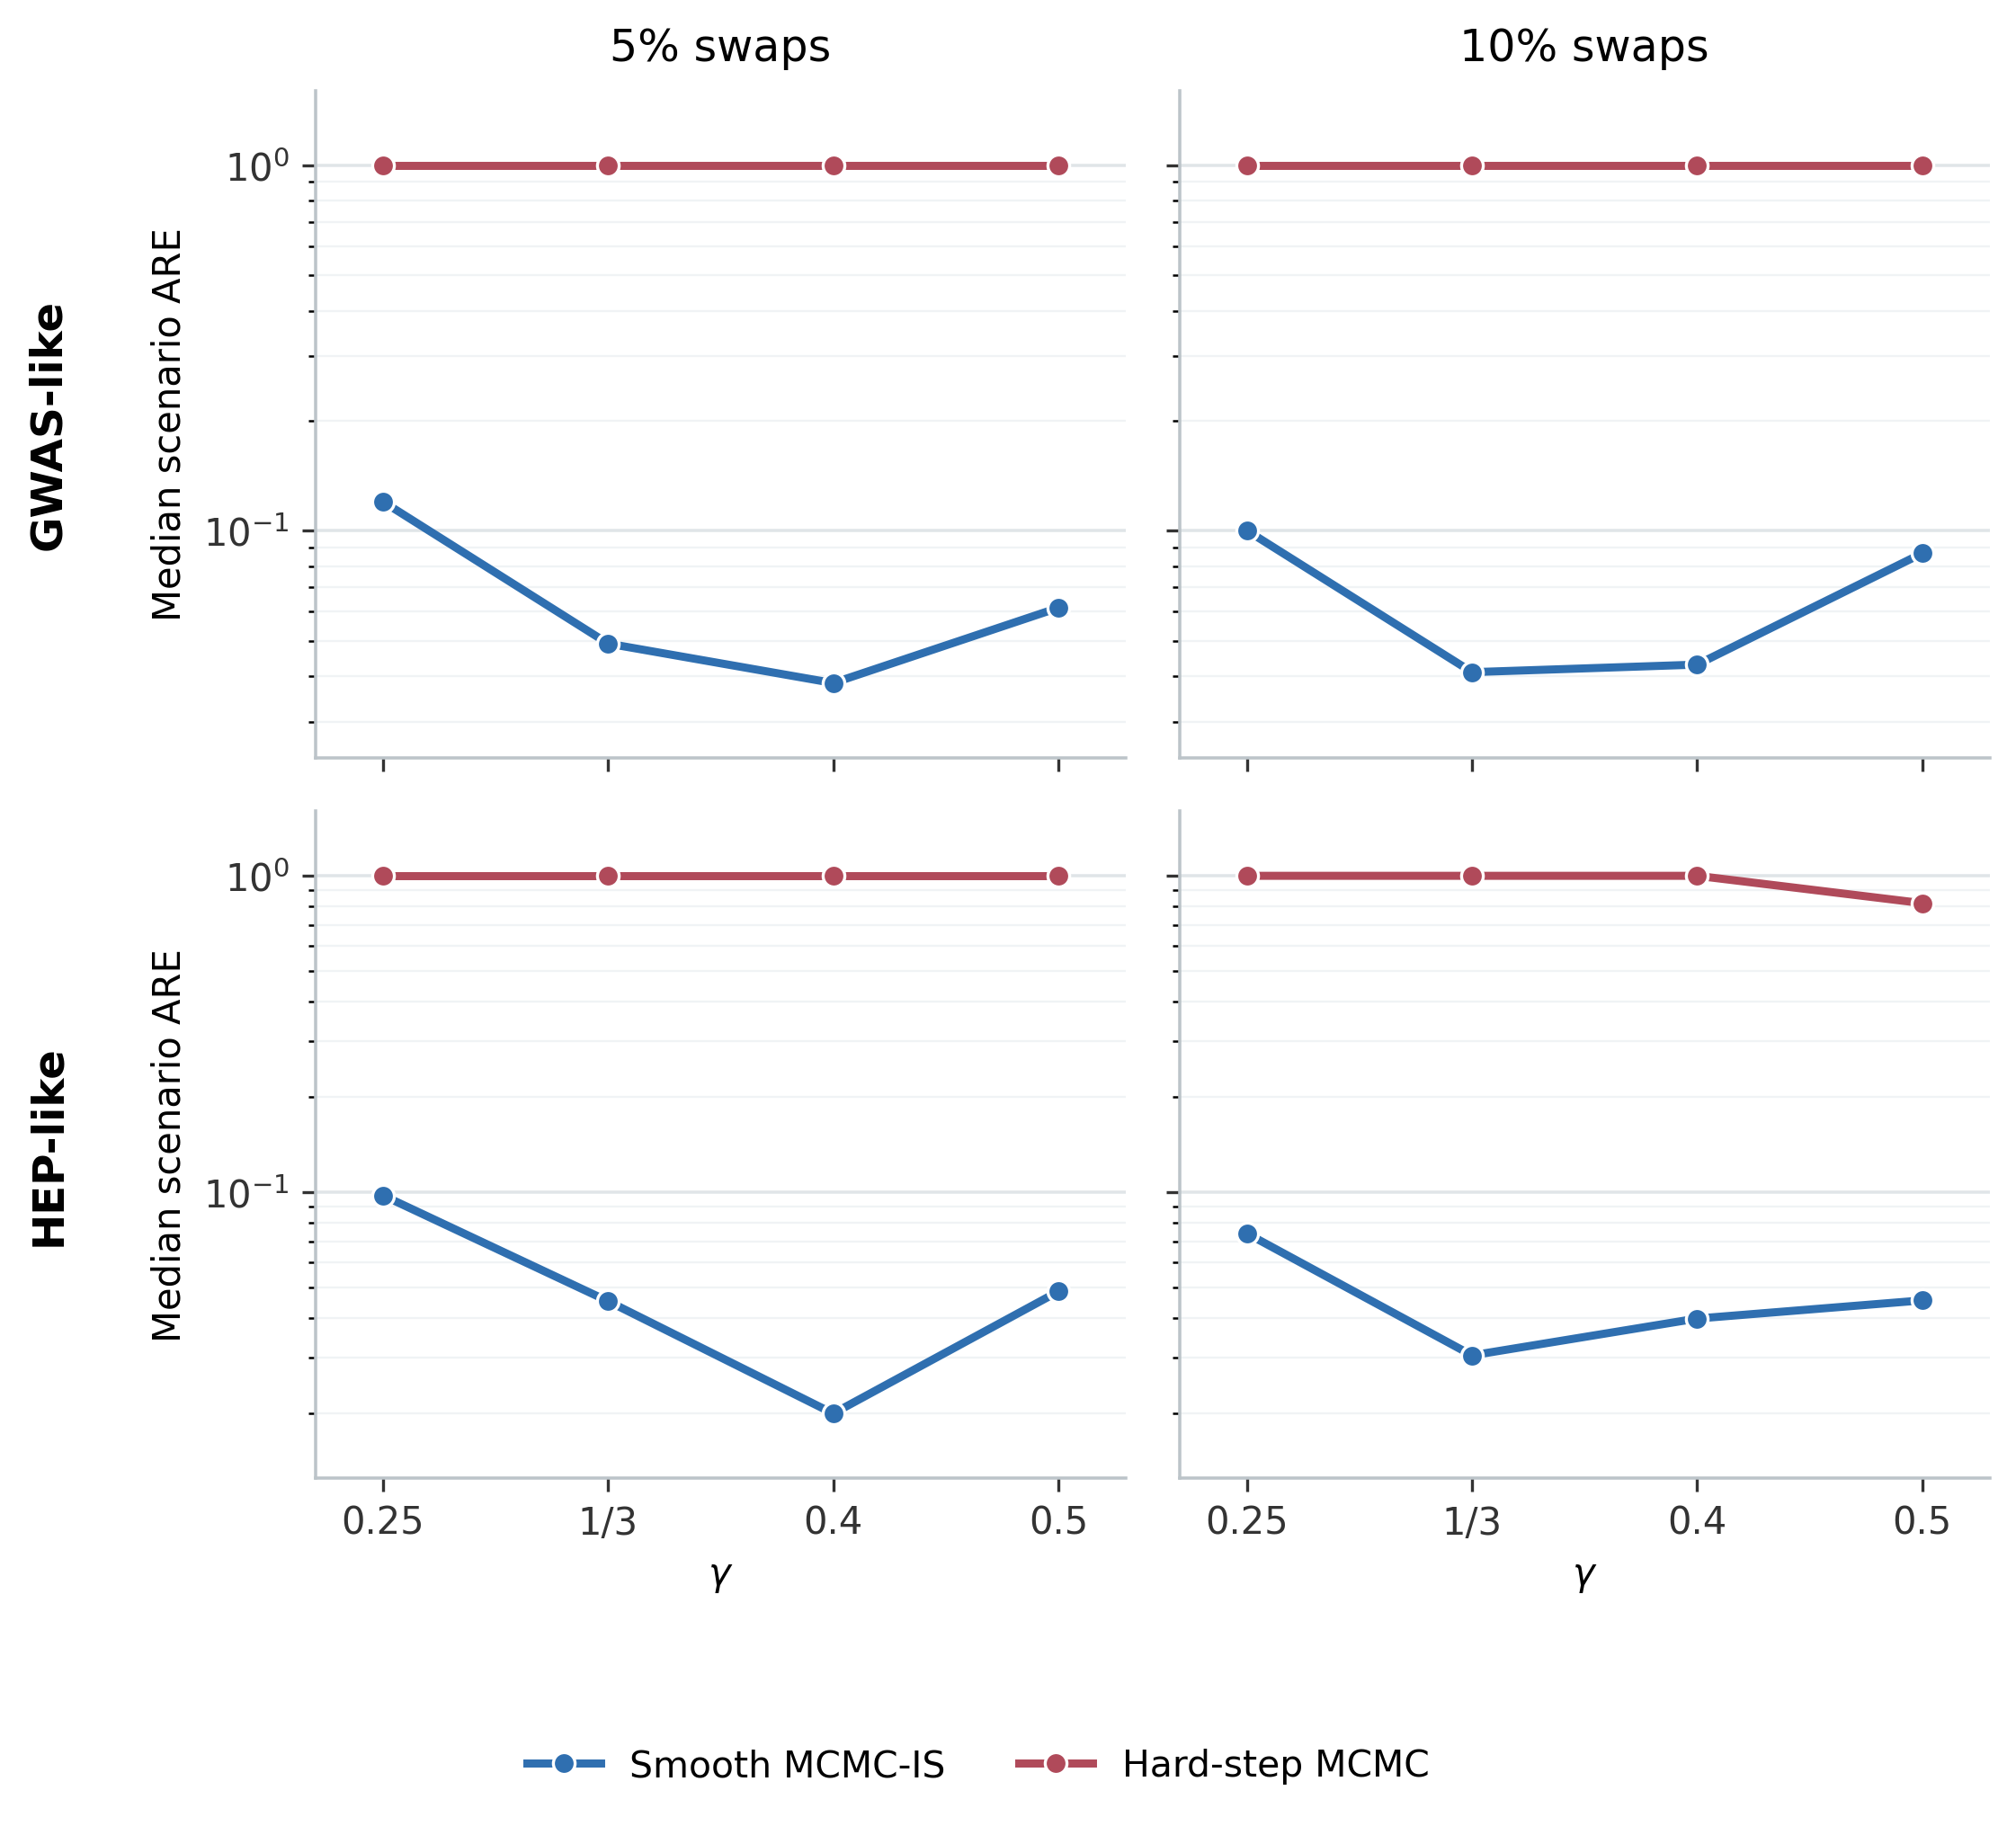

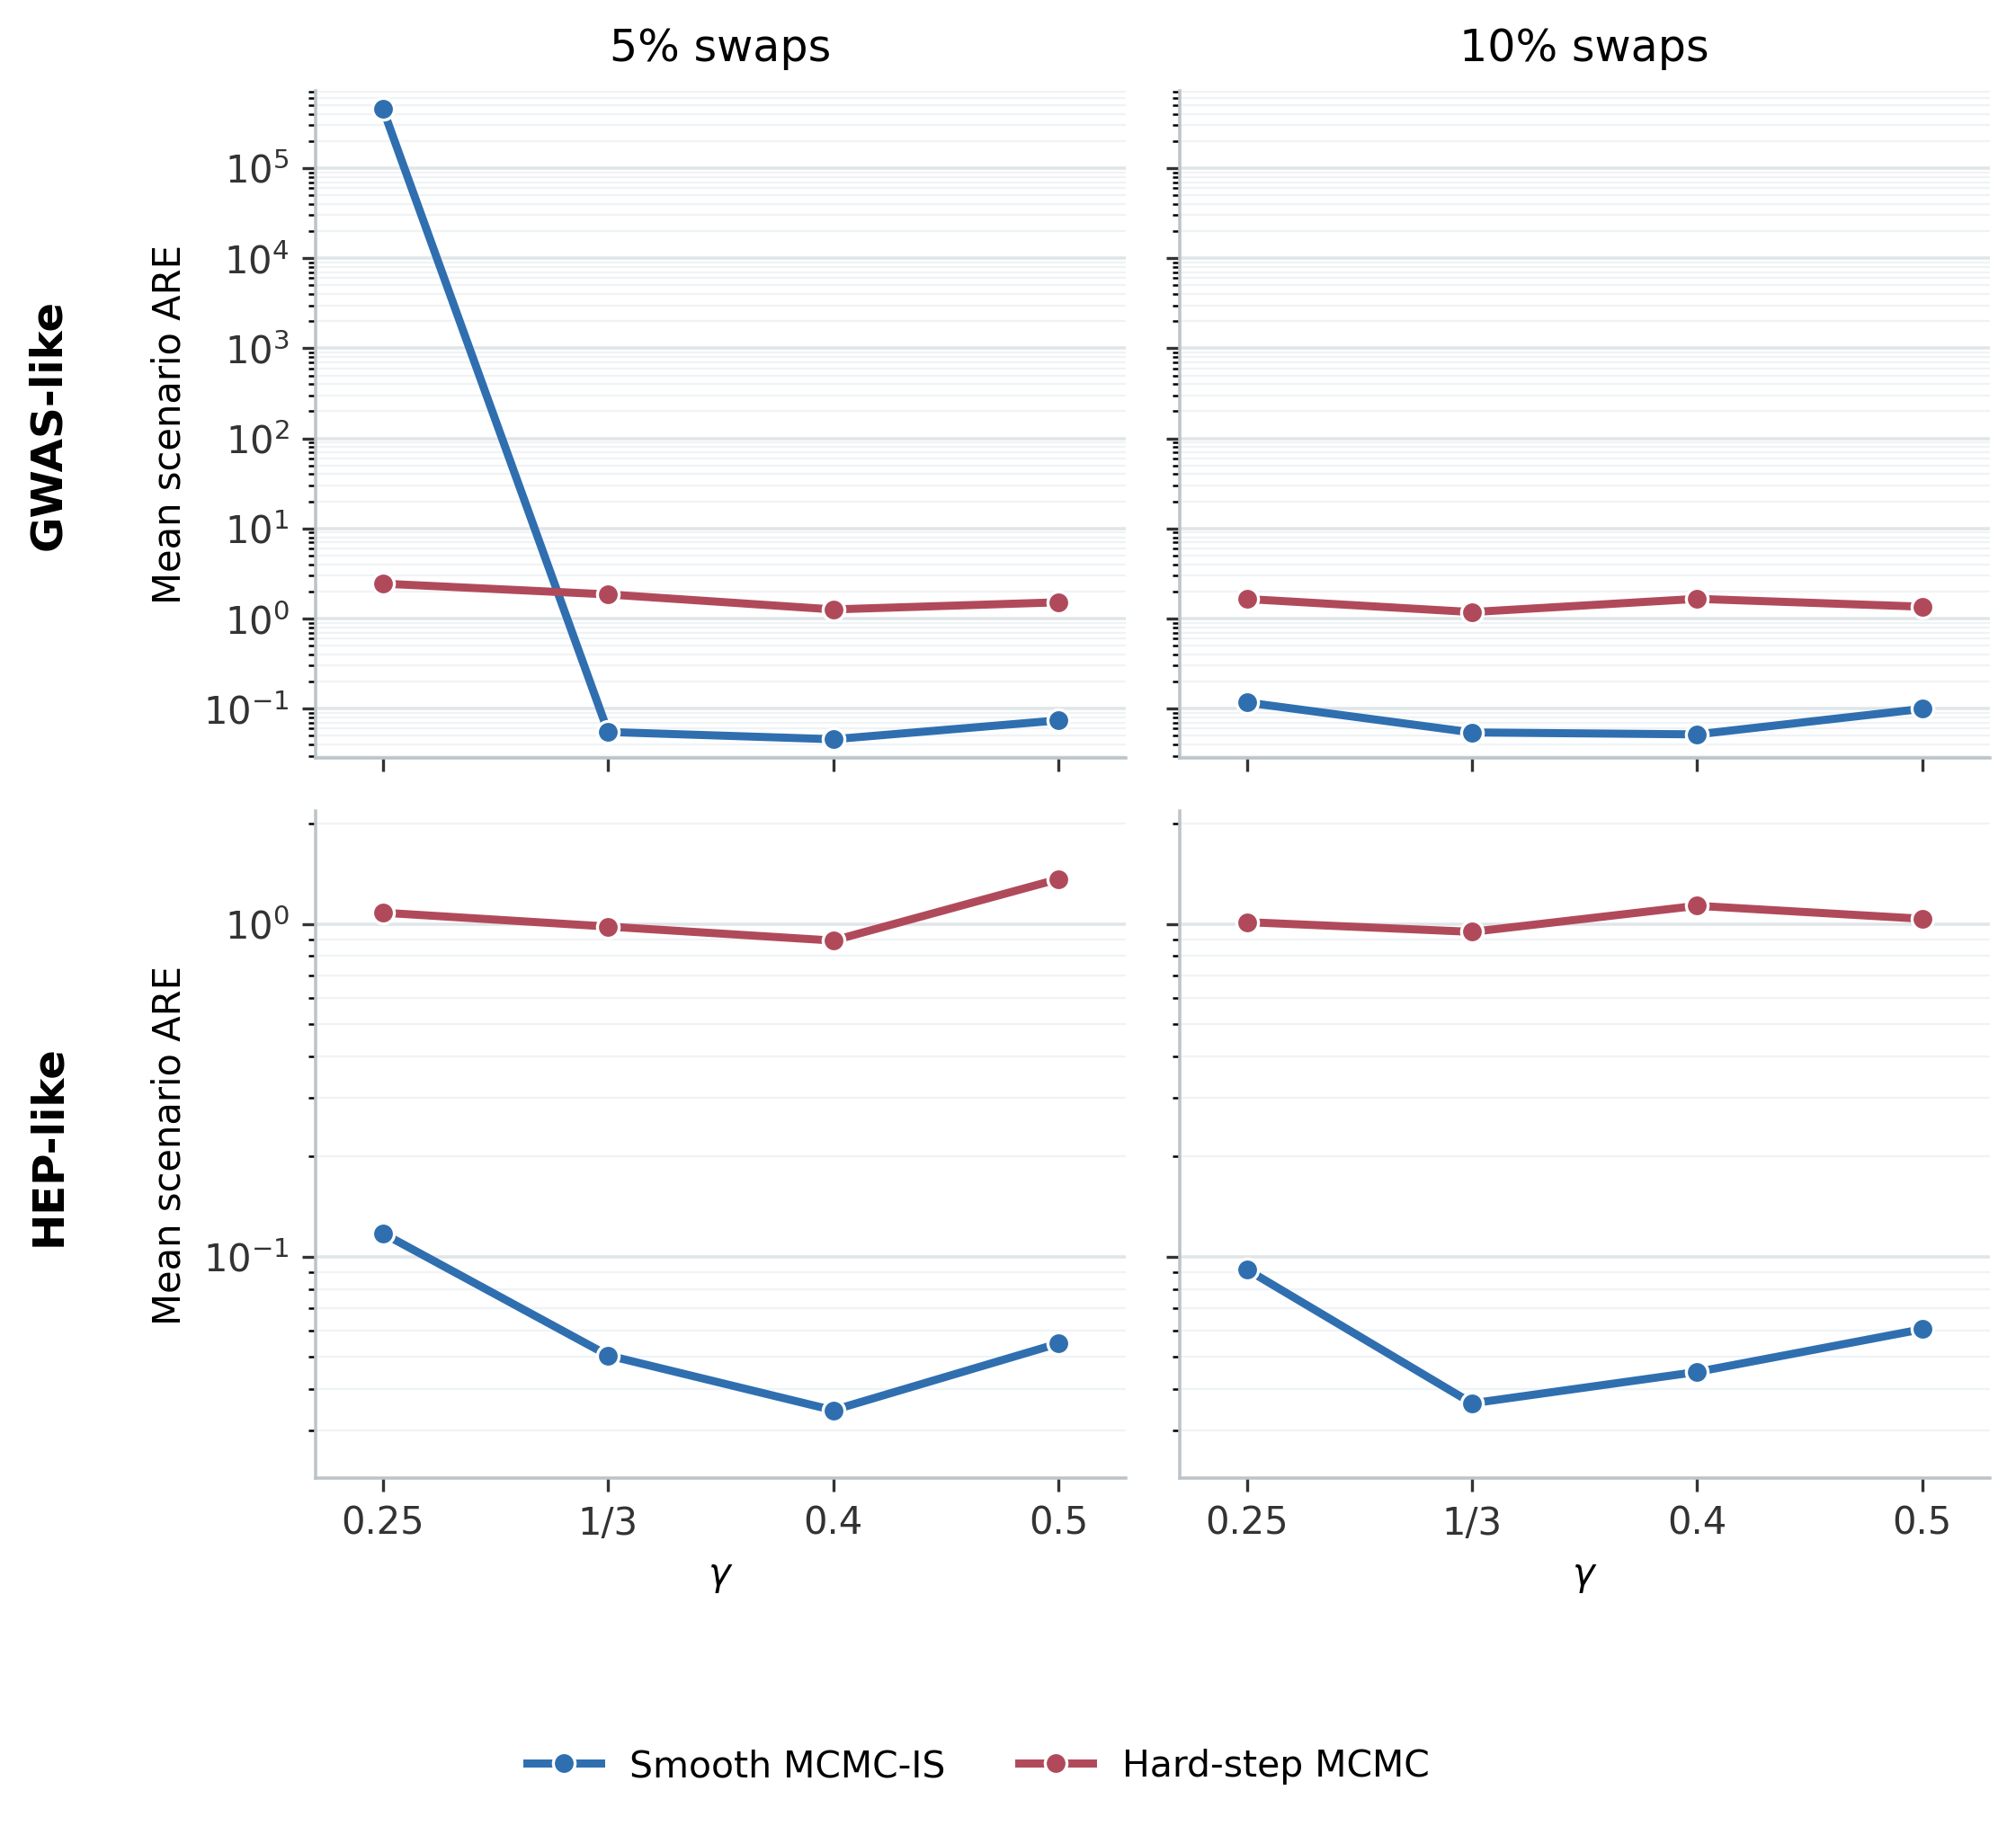

Saved Figure 1 median variant to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure1_tilt_gamma_median_rrmse.png
Saved Figure 1 mean variant to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure1_tilt_gamma_mean_rrmse.png
Saved appendix Figure 1 variants to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure1_tilt_gamma_median_rrmse_budget_1m.png and /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure1_tilt_gamma_mean_rrmse_budget_1m.png
Saved appendix Figure 1 variants to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_

,family,method,swap_fraction,gamma_label,gamma,checkpoint,n_scenarios,median_scenario_are,mean_scenario_are,p90_scenario_are,cross_scenario_rrmse,median_scenario_rrmse,relative_rmse,mean_scenario_rrmse,p90_scenario_rrmse,mean_abs_log10_error,zero_estimate_rate
0,gwas,hard_step,0.05,0.25,0.250000,5000000,50,1.000000,2.439875,1.000000,8.447649e+00,1.000000,8.447649e+00,2.439875,1.000000,1.511103,0.96
1,gwas,hard_step,0.05,0.333333333333,0.333333,5000000,50,1.000000,1.853488,1.565780,4.672636e+00,1.000000,4.672636e+00,1.853488,1.565780,0.768792,0.88
2,gwas,hard_step,0.05,0.4,0.400000,5000000,50,1.000000,1.261913,1.000000,2.253209e+00,1.000000,2.253209e+00,1.261913,1.000000,0.533777,0.92
3,gwas,hard_step,0.05,0.5,0.500000,5000000,50,1.000000,1.514763,1.592247,2.733843e+00,1.000000,2.733843e+00,1.514763,1.592247,0.643117,0.84
4,gwas,hard_step,0.10,0.25,0.250000,5000000,50,1.000000,1.647411,2.617215,2.453853e+00,1.000000,2.453853e+00,1.647411,2.617215,0.691406,0.82
5,gwas,hard_step,0.10,0.333333333333,0.333333,5000000,50,1.000000,1.180134,1.000000,1.494216e+00,1.000000,1.494216e+00,1.180134,1.000000,0.714422,0.94
6,gwas,hard_step,0.10,0.4,0.400000,5000000,50,1.000000,1.654596,2.472162,3.022773e+00,1.000000,3.022773e+00,1.654596,2.472162,0.580633,0.80
7,gwas,hard_step,0.10,0.5,0.500000,5000000,50,1.000000,1.354307,2.945479,1.689943e+00,1.000000,1.689943e+00,1.354307,2.945479,0.629438,0.86
8,gwas,mcmc_is_no_oracle,0.05,0.25,0.250000,5000000,50,0.120053,452723.589710,0.245505,3.201238e+06,0.120053,3.201238e+06,452723.589710,0.245505,0.194533,0.00
9,gwas,mcmc_is_no_oracle,0.05,0.333333333333,0.333333,5000000,50,0.049091,0.055059,0.103894,6.806044e-02,0.049091,6.806044e-02,0.055059,0.103894,0.023852,0.00


In [7]:
figure_dir = (run_dir / "figures") if (SAVE_OUTPUTS and run_dir is not None) else None
figure_support_dir = (figure_dir / "support") if figure_dir is not None else None
if figure_support_dir is not None:
    figure_support_dir.mkdir(parents=True, exist_ok=True)

def figure_budget_suffix(budget: int) -> str:
    if int(budget) == int(MAX_BUDGET):
        return ""
    label = f"{float(budget) / 1_000_000.0:g}".replace(".", "p")
    return f"_budget_{label}m"

figure_budgets = tuple(dict.fromkeys((*APPENDIX_FIGURE_BUDGETS, MAX_BUDGET)))
figure1_summaries = {}
for figure_budget in figure_budgets:
    suffix = figure_budget_suffix(int(figure_budget))
    fig1_median_path = (figure_support_dir / f"figure1_tilt_gamma_median_rrmse{suffix}.png") if figure_support_dir is not None else None
    fig1_mean_path = (figure_support_dir / f"figure1_tilt_gamma_mean_rrmse{suffix}.png") if figure_support_dir is not None else None
    figure1_median_summary = plot_threshold_grid_tilt_family_rrmse(
        all_records,
        max_budget=int(figure_budget),
        metric="median",
        families=tuple(FAMILIES),
        gamma_values=tuple(GAMMAS),
        swap_fractions=tuple(SWAP_FRACTIONS),
        save_path=fig1_median_path,
        table_save_path=(figure_support_dir / f"figure1_tilt_gamma_median_rrmse{suffix}_summary.json") if figure_support_dir is not None else None,
    )
    figure1_mean_summary = plot_threshold_grid_tilt_family_rrmse(
        all_records,
        max_budget=int(figure_budget),
        metric="mean",
        families=tuple(FAMILIES),
        gamma_values=tuple(GAMMAS),
        swap_fractions=tuple(SWAP_FRACTIONS),
        save_path=fig1_mean_path,
        table_save_path=(figure_support_dir / f"figure1_tilt_gamma_mean_rrmse{suffix}_summary.json") if figure_support_dir is not None else None,
    )
    figure1_summaries[int(figure_budget)] = {
        "median": figure1_median_summary,
        "mean": figure1_mean_summary,
        "median_path": fig1_median_path,
        "mean_path": fig1_mean_path,
    }
    if figure_dir is not None:
        plot_threshold_grid_tilt_family_rrmse(
            all_records,
            max_budget=int(figure_budget),
            metric="median",
            families=tuple(FAMILIES),
            gamma_values=tuple(GAMMAS),
            swap_fractions=tuple(SWAP_FRACTIONS),
            save_path=figure_dir / f"figure1_tilt_gamma_median_rrmse{suffix}.pdf",
        )
        plot_threshold_grid_tilt_family_rrmse(
            all_records,
            max_budget=int(figure_budget),
            metric="mean",
            families=tuple(FAMILIES),
            gamma_values=tuple(GAMMAS),
            swap_fractions=tuple(SWAP_FRACTIONS),
            save_path=figure_dir / f"figure1_tilt_gamma_mean_rrmse{suffix}.pdf",
        )
figure1_median_summary = figure1_summaries[int(MAX_BUDGET)]["median"]
figure1_mean_summary = figure1_summaries[int(MAX_BUDGET)]["mean"]
fig1_median_path = figure1_summaries[int(MAX_BUDGET)]["median_path"]
fig1_mean_path = figure1_summaries[int(MAX_BUDGET)]["mean_path"]
if fig1_median_path is not None:
    display(Image(filename=str(fig1_median_path)))
    display(Image(filename=str(fig1_mean_path)))
    print(f"Saved Figure 1 median variant to {fig1_median_path}")
    print(f"Saved Figure 1 mean variant to {fig1_mean_path}")
    if APPENDIX_FIGURE_BUDGETS:
        for appendix_budget in APPENDIX_FIGURE_BUDGETS:
            paths = figure1_summaries[int(appendix_budget)]
            print(f"Saved appendix Figure 1 variants to {paths['median_path']} and {paths['mean_path']}")
display(
    pd.DataFrame(figure1_median_summary)
    .query("method in ['mcmc_is_no_oracle', 'hard_step']")
    .sort_values(["family", "method", "swap_fraction", "gamma"])
    .reset_index(drop=True)
)

## Figure 2: Practical Takeaway

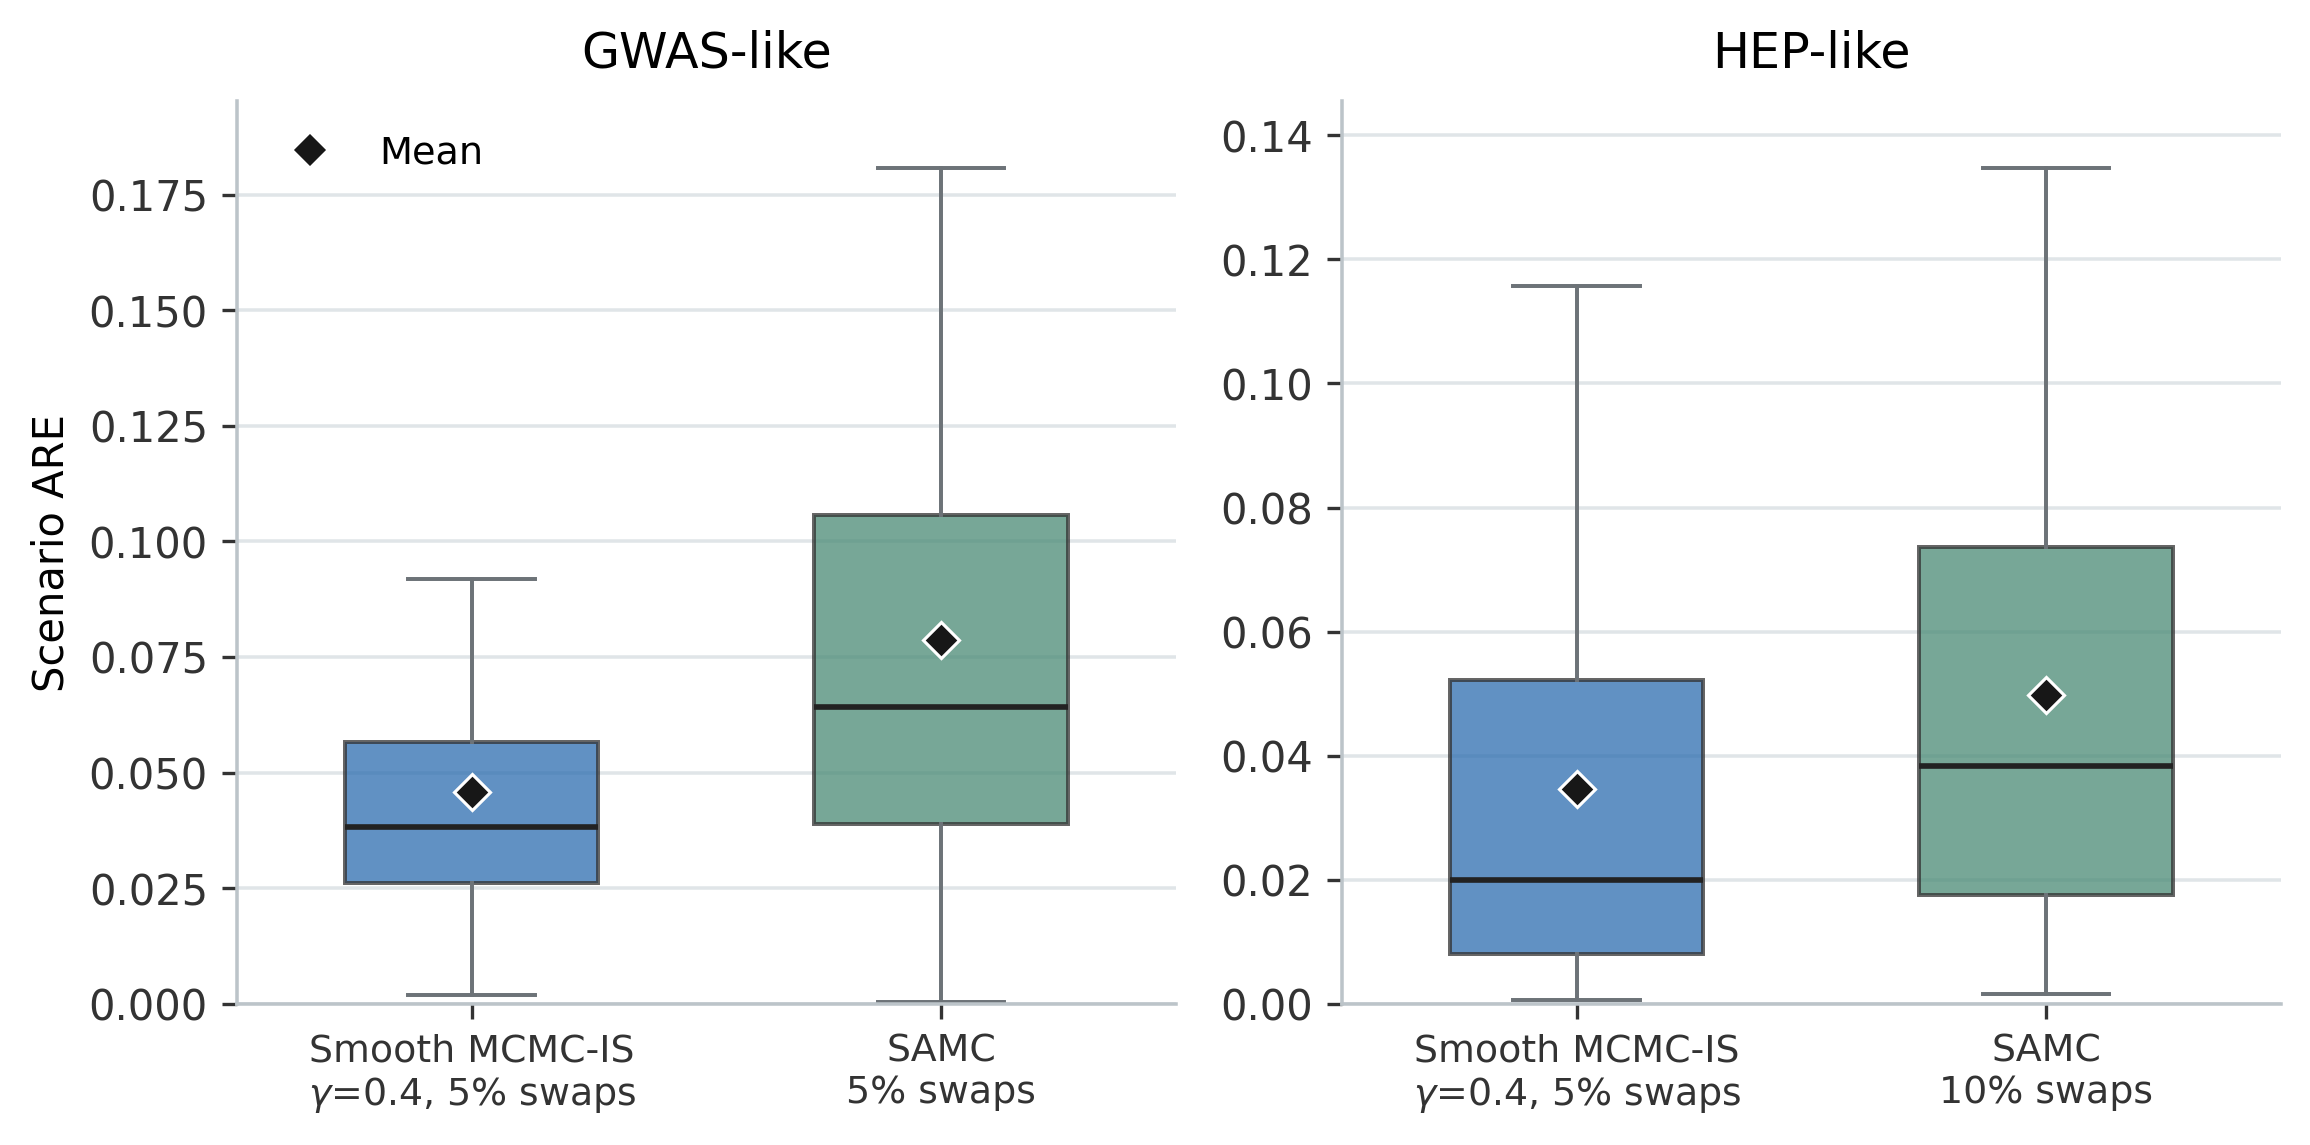

Saved Figure 2 to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure2_best_smooth_vs_samc_rrmse.png
Saved appendix Figure 2 to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure2_best_smooth_vs_samc_rrmse_budget_1m.png
Saved appendix Figure 2 to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure2_best_smooth_vs_samc_rrmse_budget_2p5m.png


,family,method,swap_fraction,gamma_label,gamma,checkpoint,n_scenarios,median_scenario_are,mean_scenario_are,p90_scenario_are,cross_scenario_rrmse,median_scenario_rrmse,relative_rmse,mean_scenario_rrmse,p90_scenario_rrmse,mean_abs_log10_error,zero_estimate_rate,display_method,config_label,selection_metric,selection_value,scenario_are_q25,scenario_are_q75,scenario_are_min,scenario_are_max,scenario_rrmse_q25,scenario_rrmse_q75,scenario_rrmse_min,scenario_rrmse_max,n_boxplot_scenarios
0,gwas,mcmc_is_no_oracle,0.05,0.4,0.4,5000000,50,0.038298,0.045735,0.093844,0.058382,0.038298,0.058382,0.045735,0.093844,0.020164,0.0,Smooth MCMC-IS,"5%, gamma=0.4",median,0.038298,0.026098,0.056660,0.001990,0.187233,0.026098,0.056660,0.001990,0.187233,50
1,gwas,samc,0.05,none,NaN,5000000,50,0.064286,0.078685,0.144504,0.100147,0.064286,0.100147,0.078685,0.144504,0.033774,0.0,SAMC,5%,median,0.064286,0.038832,0.105671,0.000387,0.296110,0.038832,0.105671,0.000387,0.296110,50
2,hep,mcmc_is_no_oracle,0.05,0.4,0.4,5000000,50,0.020024,0.034569,0.071147,0.047722,0.020024,0.047722,0.034569,0.071147,0.014977,0.0,Smooth MCMC-IS,"5%, gamma=0.4",median,0.020024,0.007989,0.052177,0.000687,0.120161,0.007989,0.052177,0.000687,0.120161,50
3,hep,samc,0.10,none,NaN,5000000,50,0.038367,0.049779,0.107168,0.061890,0.038367,0.061890,0.049779,0.107168,0.021710,0.0,SAMC,10%,median,0.038367,0.017605,0.073716,0.001552,0.134764,0.017605,0.073716,0.001552,0.134764,50


In [8]:
figure2_summaries = {}
for figure_budget in figure_budgets:
    suffix = figure_budget_suffix(int(figure_budget))
    fig2_path = (figure_support_dir / f"figure2_best_smooth_vs_samc_rrmse{suffix}.png") if figure_support_dir is not None else None
    figure2_summary = plot_threshold_grid_best_practical_rrmse(
        all_records,
        max_budget=int(figure_budget),
        families=tuple(FAMILIES),
        selection_metric="median",
        save_path=fig2_path,
        table_save_path=(figure_support_dir / f"figure2_best_smooth_vs_samc_rrmse{suffix}_summary.json") if figure_support_dir is not None else None,
    )
    figure2_summaries[int(figure_budget)] = {
        "summary": figure2_summary,
        "path": fig2_path,
    }
    if figure_dir is not None:
        plot_threshold_grid_best_practical_rrmse(
            all_records,
            max_budget=int(figure_budget),
            families=tuple(FAMILIES),
            selection_metric="median",
            save_path=figure_dir / f"figure2_best_smooth_vs_samc_rrmse{suffix}.pdf",
        )
figure2_summary = figure2_summaries[int(MAX_BUDGET)]["summary"]
fig2_path = figure2_summaries[int(MAX_BUDGET)]["path"]
if fig2_path is not None:
    display(Image(filename=str(fig2_path)))
    print(f"Saved Figure 2 to {fig2_path}")
    if APPENDIX_FIGURE_BUDGETS:
        for appendix_budget in APPENDIX_FIGURE_BUDGETS:
            print(f"Saved appendix Figure 2 to {figure2_summaries[int(appendix_budget)]['path']}")
display(pd.DataFrame(figure2_summary))

## Figure 3: Scenario-Level Comparison

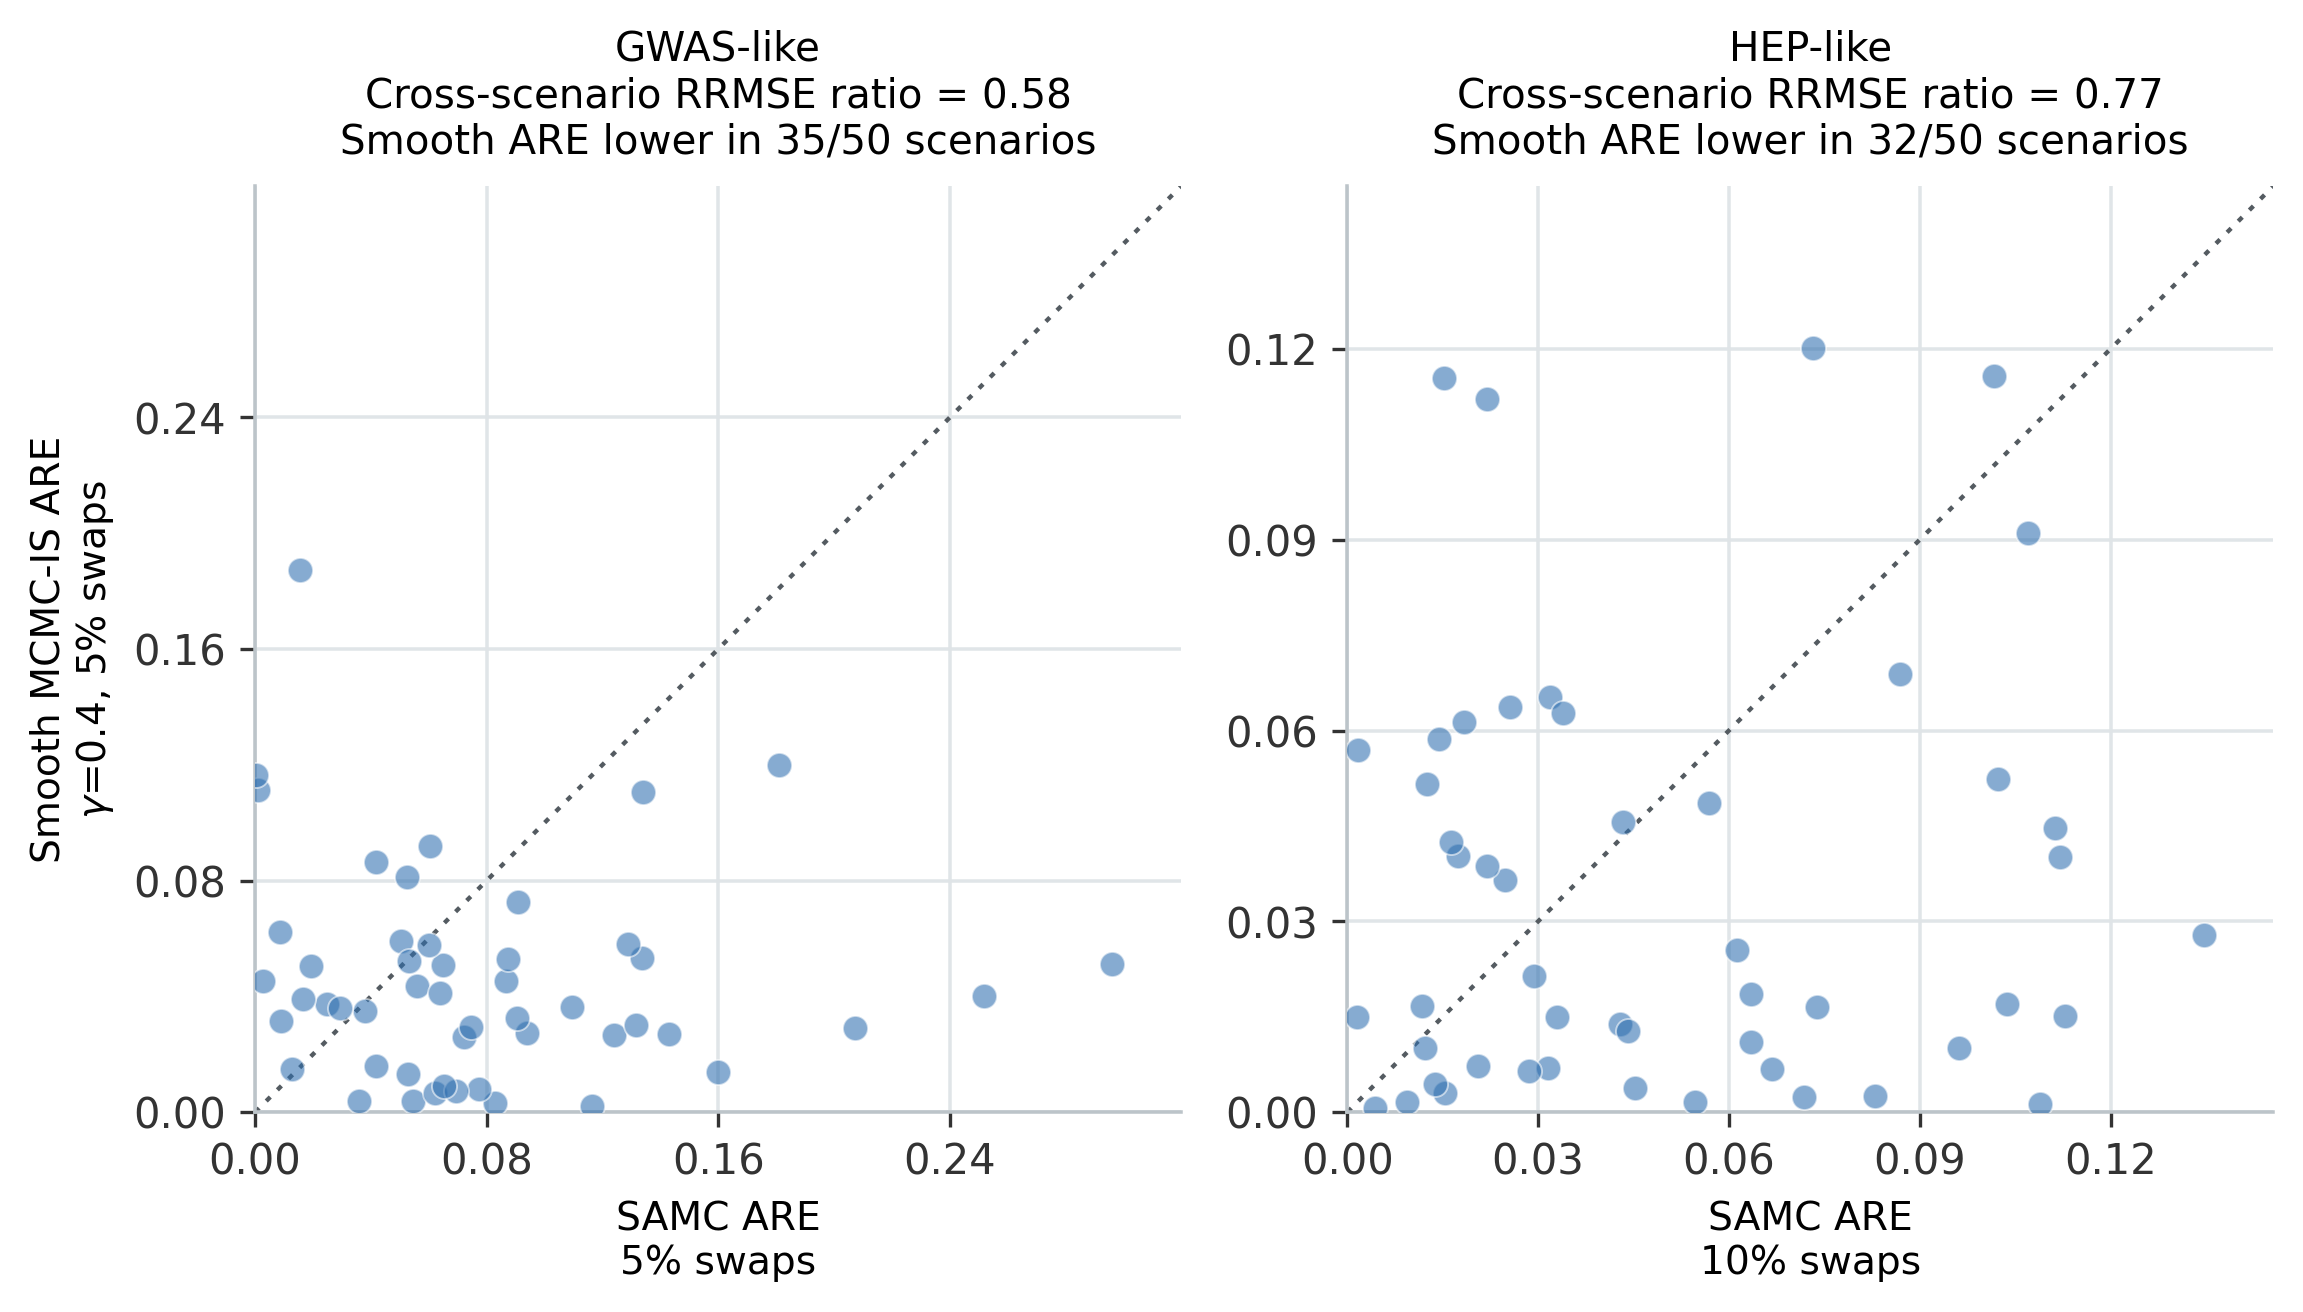

Saved Figure 3 to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_best_smooth_vs_samc_scenario_rrmse.png
Saved appendix Figure 3 to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_best_smooth_vs_samc_scenario_rrmse_budget_1m.png
Saved appendix Figure 3 to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_best_smooth_vs_samc_scenario_rrmse_budget_2p5m.png


,family,checkpoint,selection_metric,smooth_config_label,samc_config_label,n_paired_scenarios,cross_scenario_rrmse_ratio_smooth_over_samc,smooth_cross_scenario_rrmse,samc_cross_scenario_rrmse,n_smooth_are_lt_samc,median_are_ratio_smooth_over_samc,prob_smooth_are_lt_samc,median_smooth_are,median_samc_are,median_rrmse_ratio_smooth_over_samc,prob_smooth_rrmse_lt_samc,median_smooth_rrmse,median_samc_rrmse
0,gwas,5000000,median,"5%, gamma=0.4",5%,50,0.582964,0.058382,0.100147,35,0.564323,0.70,0.038298,0.064286,0.564323,0.70,0.038298,0.064286
1,hep,5000000,median,"5%, gamma=0.4",10%,50,0.771088,0.047722,0.061890,32,0.434936,0.64,0.020024,0.038367,0.434936,0.64,0.020024,0.038367


In [9]:
figure3_summaries = {}
for figure_budget in figure_budgets:
    suffix = figure_budget_suffix(int(figure_budget))
    fig3_path = (figure_support_dir / f"figure3_best_smooth_vs_samc_scenario_rrmse{suffix}.png") if figure_support_dir is not None else None
    figure3_summary = plot_threshold_grid_best_practical_scenario_scatter(
        all_records,
        max_budget=int(figure_budget),
        families=tuple(FAMILIES),
        selection_metric="median",
        save_path=fig3_path,
        table_save_path=(figure_support_dir / f"figure3_best_smooth_vs_samc_scenario_rrmse{suffix}_summary.json") if figure_support_dir is not None else None,
    )
    figure3_summaries[int(figure_budget)] = {
        "summary": figure3_summary,
        "path": fig3_path,
    }
    if figure_dir is not None:
        plot_threshold_grid_best_practical_scenario_scatter(
            all_records,
            max_budget=int(figure_budget),
            families=tuple(FAMILIES),
            selection_metric="median",
            save_path=figure_dir / f"figure3_best_smooth_vs_samc_scenario_rrmse{suffix}.pdf",
        )
figure3_summary = figure3_summaries[int(MAX_BUDGET)]["summary"]
fig3_path = figure3_summaries[int(MAX_BUDGET)]["path"]
if fig3_path is not None:
    display(Image(filename=str(fig3_path)))
    print(f"Saved Figure 3 to {fig3_path}")
    if APPENDIX_FIGURE_BUDGETS:
        for appendix_budget in APPENDIX_FIGURE_BUDGETS:
            print(f"Saved appendix Figure 3 to {figure3_summaries[int(appendix_budget)]['path']}")
display(pd.DataFrame(figure3_summary).drop(columns=["paired_points"], errors="ignore"))

## Figure 4: Threshold-Scale Estimates

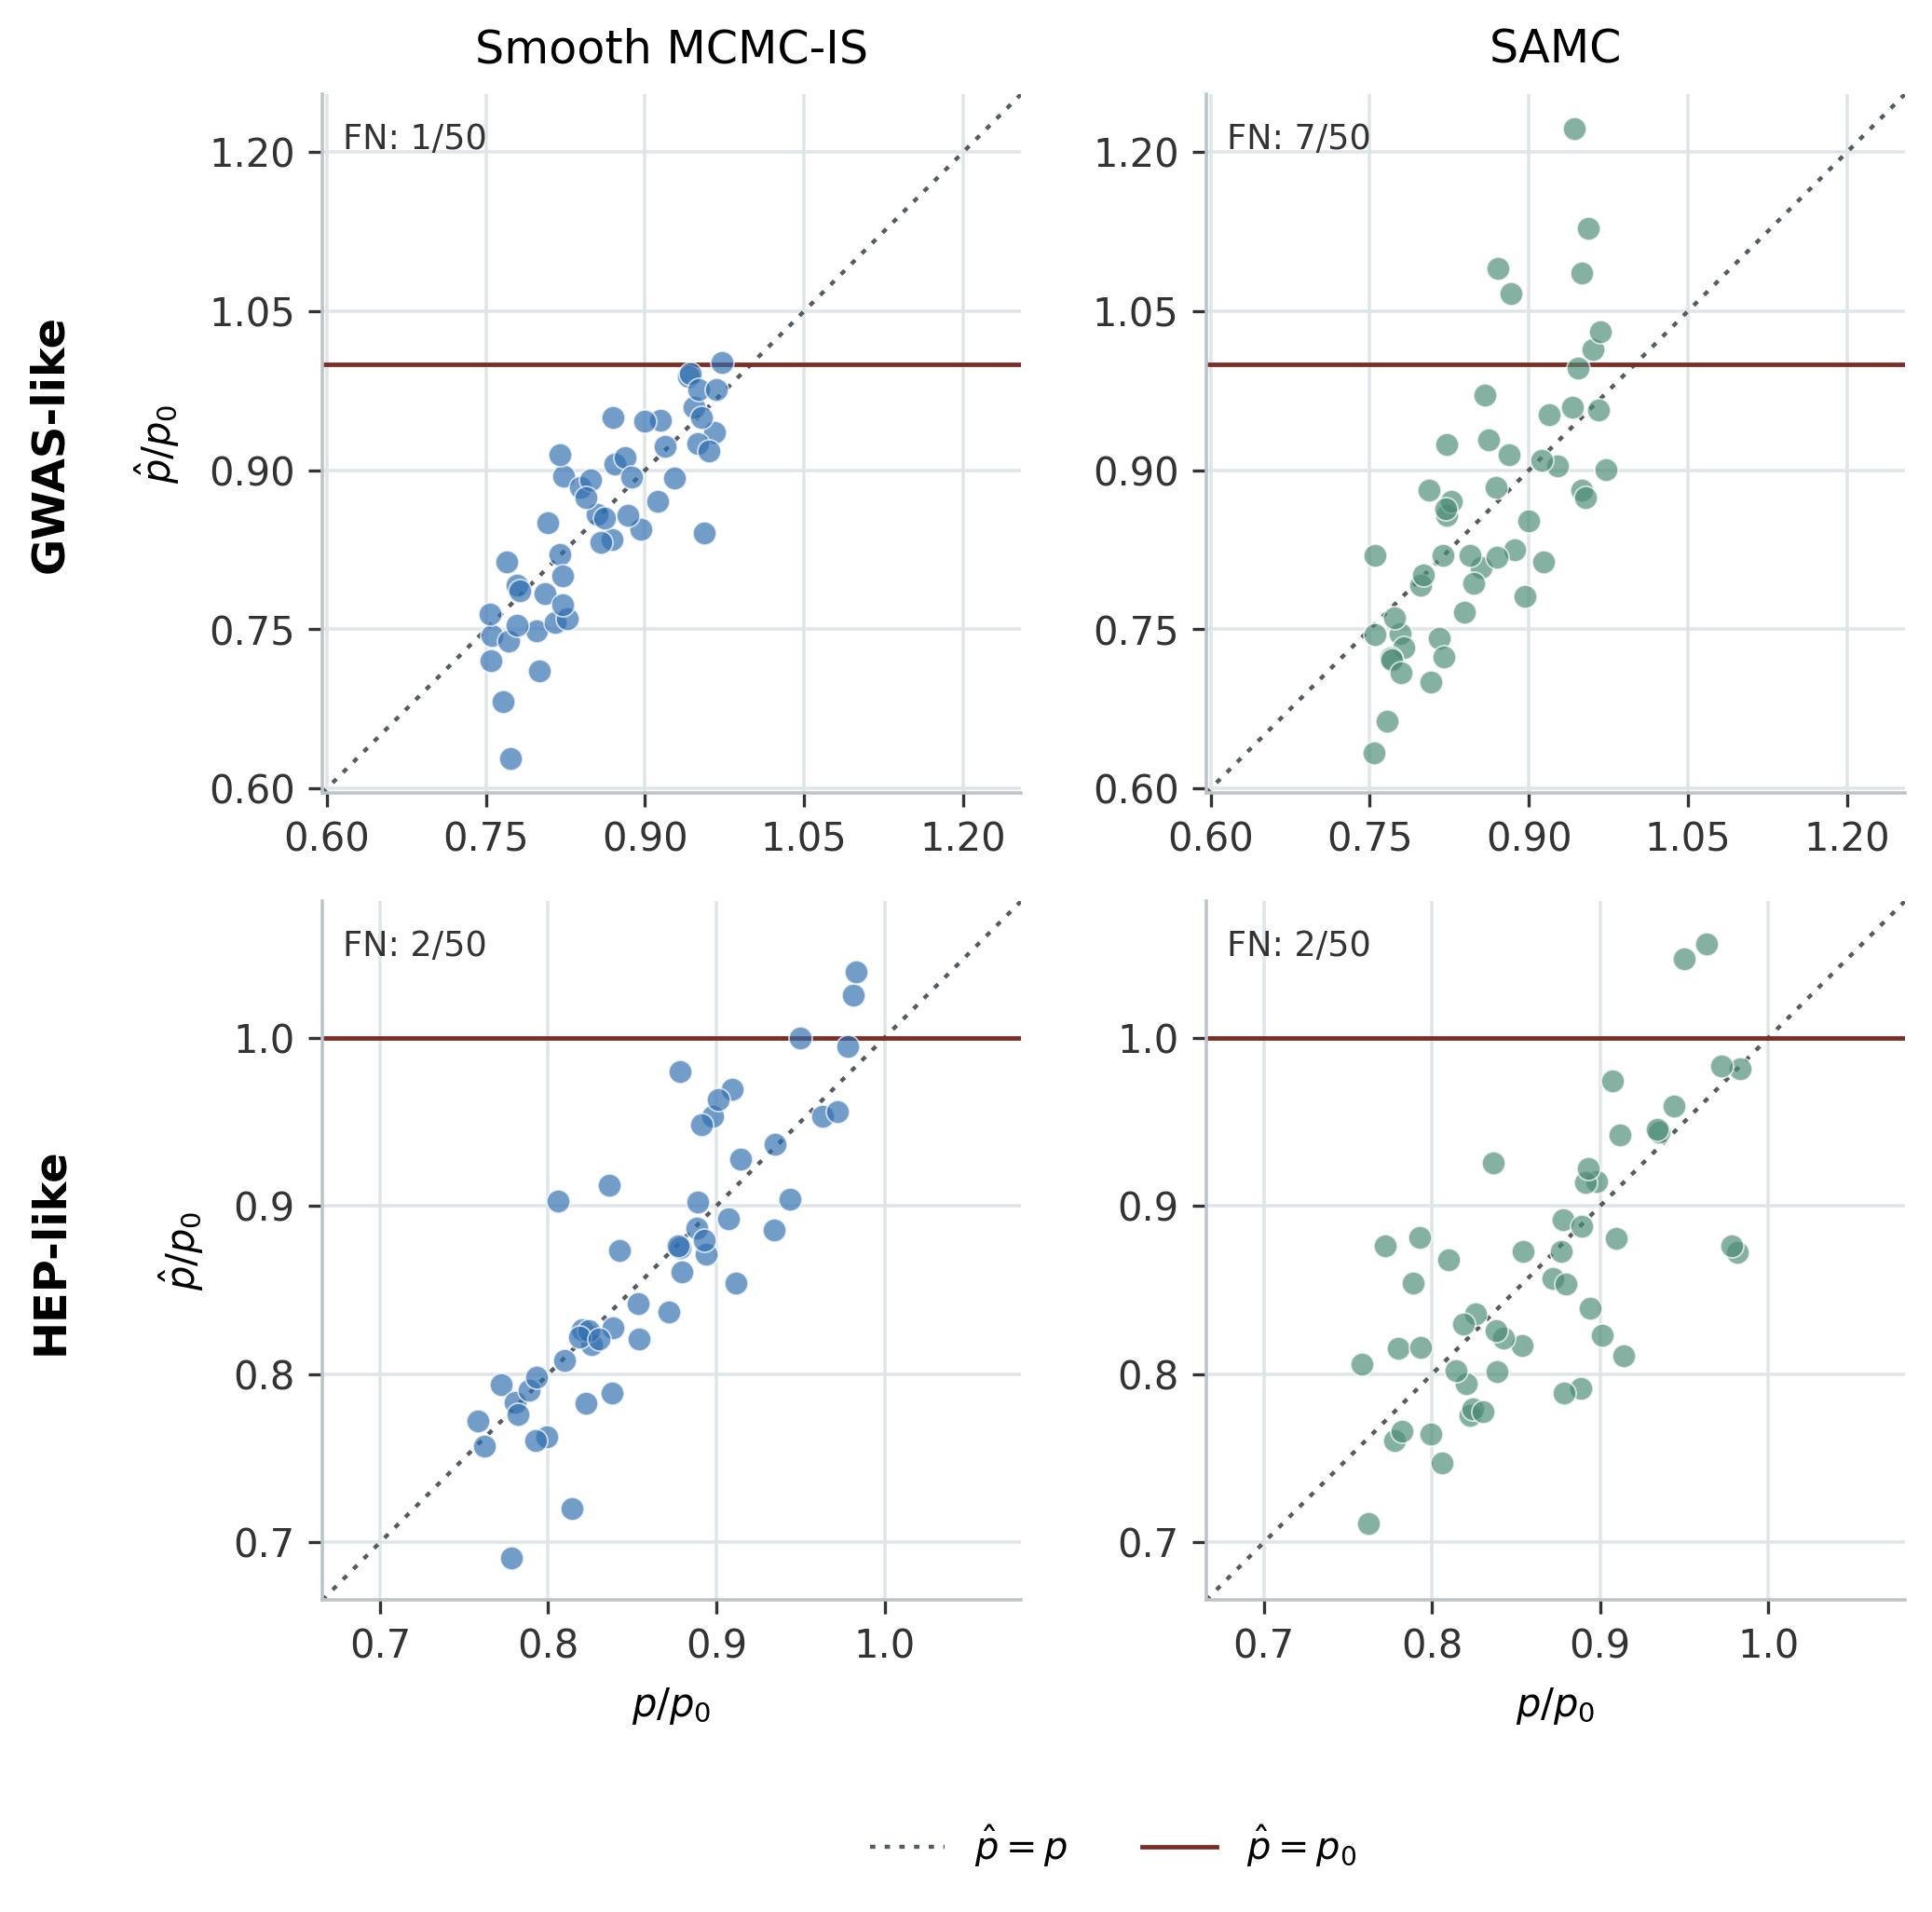

Saved Figure 4 to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure4_estimate_vs_threshold_ratio.png


,family,display_method,config_label,n_scenarios,n_estimate_above_threshold,n_false_negative,median_abs_ratio_error
0,gwas,SAMC,5%,50,7,7,0.054242
1,gwas,Smooth MCMC-IS,"5%, gamma=0.4",50,1,1,0.033603
2,hep,SAMC,10%,50,2,2,0.032789
3,hep,Smooth MCMC-IS,"5%, gamma=0.4",50,2,2,0.017701


In [10]:
fig4_path = (figure_support_dir / "figure4_estimate_vs_threshold_ratio.png") if figure_support_dir is not None else None
figure4_points = plot_threshold_grid_estimate_vs_threshold_ratio(
    all_records,
    max_budget=int(MAX_BUDGET),
    families=tuple(FAMILIES),
    selection_metric="median",
    save_path=fig4_path,
    table_save_path=(figure_support_dir / "figure4_estimate_vs_threshold_ratio_points.json") if figure_support_dir is not None else None,
)
if figure_dir is not None:
    plot_threshold_grid_estimate_vs_threshold_ratio(
        all_records,
        max_budget=int(MAX_BUDGET),
        families=tuple(FAMILIES),
        selection_metric="median",
        save_path=figure_dir / "figure4_estimate_vs_threshold_ratio.pdf",
    )
if fig4_path is not None:
    display(Image(filename=str(fig4_path)))
    print(f"Saved Figure 4 to {fig4_path}")
figure4_summary = (
    pd.DataFrame(figure4_points)
    .groupby(["family", "display_method", "config_label"], dropna=False)
    .agg(
        n_scenarios=("scenario", "count"),
        n_estimate_above_threshold=("estimate_above_threshold", "sum"),
        n_false_negative=("false_negative", "sum"),
        median_abs_ratio_error=("abs_ratio_error", "median"),
    )
    .reset_index()
)
display(figure4_summary)

## Bootstrap Diagnostics

In [11]:
bootstrap_summaries = {}
bootstrap_summary_rows = []
bootstrap_budgets = tuple(CHECKPOINTS)

def bootstrap_budget_suffix(budget: int) -> str:
    if int(budget) % 1_000_000 == 0:
        label = f"{int(budget) // 1_000_000}m"
    elif int(budget) % 1_000 == 0:
        label = f"{int(budget) // 1_000}k"
    else:
        label = str(int(budget))
    return f"_budget_{label}"

for figure_budget in bootstrap_budgets:
    suffix = bootstrap_budget_suffix(int(figure_budget))
    bootstrap_path = (
        figure_support_dir / f"figure3_bootstrap_diagnostics{suffix}.json"
    ) if figure_support_dir is not None else None
    bootstrap_rows = bootstrap_threshold_grid_best_practical_diagnostics(
        all_records,
        max_budget=int(figure_budget),
        families=tuple(FAMILIES),
        selection_metric="median",
        n_bootstrap=int(BOOTSTRAP_RESAMPLES),
        seed=int(BOOTSTRAP_SEED + int(figure_budget)),
        save_path=bootstrap_path,
    )
    bootstrap_summaries[int(figure_budget)] = {
        "summary": bootstrap_rows,
        "path": bootstrap_path,
    }
    compact_rows = [
        {
            key: value
            for key, value in row.items()
            if key not in {"bootstrap_rrmse_ratios", "bootstrap_win_rates", "paired_points"}
        }
        for row in bootstrap_rows
    ]
    bootstrap_summary_rows.extend(compact_rows)
    if bootstrap_path is not None:
        print(f"Saved bootstrap diagnostics to {bootstrap_path}")

bootstrap_summary_df = pd.DataFrame(bootstrap_summary_rows).sort_values(["checkpoint", "family"])
if figure_dir is not None:
    bootstrap_summary_path = figure_support_dir / "figure3_bootstrap_diagnostics_summary.json"
    bootstrap_summary_csv_path = figure_support_dir / "figure3_bootstrap_diagnostics_summary.csv"
    write_json(bootstrap_summary_path, bootstrap_summary_rows)
    bootstrap_summary_df.to_csv(bootstrap_summary_csv_path, index=False)
    print(f"Saved bootstrap diagnostic summary to {bootstrap_summary_path}")
    print(f"Saved bootstrap diagnostic summary to {bootstrap_summary_csv_path}")
display(bootstrap_summary_df)

Saved bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_diagnostics_budget_250k.json


Saved bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_diagnostics_budget_500k.json


Saved bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_diagnostics_budget_750k.json


Saved bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_diagnostics_budget_1m.json
Saved bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_diagnostics_budget_1250k.json


Saved bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_diagnostics_budget_1500k.json


...

Saved bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_diagnostics_budget_3250k.json


Saved bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_diagnostics_budget_3500k.json
Saved bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_diagnostics_budget_3750k.json


Saved bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_diagnostics_budget_4m.json
Saved bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_diagnostics_budget_4250k.json
Saved bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_diagnostics_budget_4500k.json


Saved bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_diagnostics_budget_4750k.json
Saved bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_diagnostics_budget_5m.json
Saved bootstrap diagnostic summary to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_diagnostics_summary.json
Saved bootstrap diagnostic summary to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_diagnostics_summary.csv


,family,checkpoint,config_selection_checkpoint,selection_metric,smooth_config_label,samc_config_label,n_scenarios,n_bootstrap,bootstrap_seed,observed_rrmse_ratio_smooth_over_samc,observed_smooth_cross_scenario_rrmse,observed_samc_cross_scenario_rrmse,observed_win_rate,observed_win_count,rrmse_ratio_bootstrap_mean,rrmse_ratio_bootstrap_median,rrmse_ratio_ci95_low,rrmse_ratio_ci95_high,win_rate_bootstrap_mean,win_rate_bootstrap_median,win_rate_ci95_low,win_rate_ci95_high
0,gwas,250000,250000,median,"5%, gamma=1/3",5%,50,10000,371337,0.834760,0.336366,0.402950,0.68,34,0.833446,0.828526,0.613613,1.076927,0.678776,0.68,0.54,0.8000
1,hep,250000,250000,median,"5%, gamma=1/3",5%,50,10000,371337,1.048172,0.252759,0.241143,0.44,22,1.120056,1.075889,0.657393,1.669367,0.440062,0.44,0.30,0.5800
2,gwas,500000,500000,median,"5%, gamma=1/3",5%,50,10000,621337,0.575815,0.194901,0.338478,0.66,33,0.585119,0.576331,0.430454,0.783708,0.661096,0.66,0.52,0.7800
3,hep,500000,500000,median,"10%, gamma=0.4",5%,50,10000,621337,0.776219,0.134668,0.173492,0.64,32,0.780001,0.775245,0.595098,0.985023,0.640278,0.64,0.50,0.7800
4,gwas,750000,750000,median,"5%, gamma=1/3",5%,50,10000,871337,0.470688,0.158620,0.336997,0.74,37,0.487315,0.476935,0.330485,0.697515,0.740650,0.74,0.62,0.8600
5,hep,750000,750000,median,"10%, gamma=0.4",10%,50,10000,871337,0.724848,0.105411,0.145425,0.62,31,0.732542,0.725495,0.561969,0.945827,0.620264,0.62,0.48,0.7600
6,gwas,1000000,1000000,median,"5%, gamma=0.4",10%,50,10000,1121337,0.429549,0.126475,0.294436,0.76,38,0.436723,0.431452,0.325870,0.579174,0.761342,0.76,0.64,0.8800
7,hep,1000000,1000000,median,"5%, gamma=0.4",10%,50,10000,1121337,0.698235,0.083814,0.120037,0.74,37,0.700278,0.696450,0.534577,0.882657,0.739904,0.74,0.62,0.8600
8,gwas,1250000,1250000,median,"5%, gamma=1/3",5%,50,10000,1371337,0.581684,0.131491,0.226052,0.68,34,0.589932,0.583705,0.427479,0.796398,0.678494,0.68,0.54,0.8000
9,hep,1250000,1250000,median,"5%, gamma=0.4",5%,50,10000,1371337,0.655496,0.075364,0.114973,0.74,37,0.662488,0.656543,0.506289,0.851811,0.739220,0.74,0.62,0.8600


## Bootstrap Diagnostics: Fixed 5M Configurations

In [12]:
fixed_config_bootstrap_summaries = {}
fixed_config_bootstrap_summary_rows = []
fixed_config_selection_budget = int(MAX_BUDGET)
for figure_budget in bootstrap_budgets:
    suffix = bootstrap_budget_suffix(int(figure_budget))
    bootstrap_path = (
        figure_support_dir / f"figure3_bootstrap_fixed_5m_config_diagnostics{suffix}.json"
    ) if figure_support_dir is not None else None
    bootstrap_rows = bootstrap_threshold_grid_best_practical_diagnostics(
        all_records,
        max_budget=int(figure_budget),
        config_selection_budget=fixed_config_selection_budget,
        families=tuple(FAMILIES),
        selection_metric="median",
        n_bootstrap=int(BOOTSTRAP_RESAMPLES),
        seed=int(BOOTSTRAP_SEED + 7_000_000 + int(figure_budget)),
        save_path=bootstrap_path,
    )
    fixed_config_bootstrap_summaries[int(figure_budget)] = {
        "summary": bootstrap_rows,
        "path": bootstrap_path,
    }
    compact_rows = [
        {
            key: value
            for key, value in row.items()
            if key not in {"bootstrap_rrmse_ratios", "bootstrap_win_rates", "paired_points"}
        }
        for row in bootstrap_rows
    ]
    fixed_config_bootstrap_summary_rows.extend(compact_rows)
    if bootstrap_path is not None:
        print(f"Saved fixed-config bootstrap diagnostics to {bootstrap_path}")

fixed_config_bootstrap_summary_df = (
    pd.DataFrame(fixed_config_bootstrap_summary_rows)
    .sort_values(["checkpoint", "family"])
)
if figure_dir is not None:
    fixed_summary_path = figure_support_dir / "figure3_bootstrap_fixed_5m_config_diagnostics_summary.json"
    fixed_summary_csv_path = figure_support_dir / "figure3_bootstrap_fixed_5m_config_diagnostics_summary.csv"
    write_json(fixed_summary_path, fixed_config_bootstrap_summary_rows)
    fixed_config_bootstrap_summary_df.to_csv(fixed_summary_csv_path, index=False)
    print(f"Saved fixed-config bootstrap diagnostic summary to {fixed_summary_path}")
    print(f"Saved fixed-config bootstrap diagnostic summary to {fixed_summary_csv_path}")
display(fixed_config_bootstrap_summary_df)

Saved fixed-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_5m_config_diagnostics_budget_250k.json
Saved fixed-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_5m_config_diagnostics_budget_500k.json


Saved fixed-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_5m_config_diagnostics_budget_750k.json
Saved fixed-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_5m_config_diagnostics_budget_1m.json
Saved fixed-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_5m_config_diagnostics_budget_1250k.json


Saved fixed-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_5m_config_diagnostics_budget_1500k.json
Saved fixed-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_5m_config_diagnostics_budget_1750k.json
Saved fixed-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_5m_config_diagnostics_budget_2m.json


Saved fixed-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_5m_config_diagnostics_budget_2250k.json
Saved fixed-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_5m_config_diagnostics_budget_2500k.json
Saved fixed-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_5m_config_diagnostics_budget_2750k.json


Saved fixed-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_5m_config_diagnostics_budget_3m.json
Saved fixed-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_5m_config_diagnostics_budget_3250k.json
Saved fixed-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_5m_config_diagnostics_budget_3500k.json


Saved fixed-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_5m_config_diagnostics_budget_3750k.json
Saved fixed-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_5m_config_diagnostics_budget_4m.json
Saved fixed-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_5m_config_diagnostics_budget_4250k.json


Saved fixed-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_5m_config_diagnostics_budget_4500k.json
Saved fixed-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_5m_config_diagnostics_budget_4750k.json
Saved fixed-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_5m_config_diagnostics_budget_5m.json
Saved fixed-config bootstrap diagnostic summary to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_

,family,checkpoint,config_selection_checkpoint,selection_metric,smooth_config_label,samc_config_label,n_scenarios,n_bootstrap,bootstrap_seed,observed_rrmse_ratio_smooth_over_samc,observed_smooth_cross_scenario_rrmse,observed_samc_cross_scenario_rrmse,observed_win_rate,observed_win_count,rrmse_ratio_bootstrap_mean,rrmse_ratio_bootstrap_median,rrmse_ratio_ci95_low,rrmse_ratio_ci95_high,win_rate_bootstrap_mean,win_rate_bootstrap_median,win_rate_ci95_low,win_rate_ci95_high
0,gwas,250000,5000000,median,"5%, gamma=0.4",5%,50,10000,7371337,0.951212,0.383291,0.402950,0.46,23,0.953546,0.948235,0.756888,1.183814,0.459348,0.46,0.3200,0.60
1,hep,250000,5000000,median,"5%, gamma=0.4",10%,50,10000,7371337,0.921330,0.247283,0.268398,0.58,29,0.923627,0.917647,0.729924,1.152000,0.580696,0.58,0.4400,0.72
2,gwas,500000,5000000,median,"5%, gamma=0.4",5%,50,10000,7621337,0.645314,0.218425,0.338478,0.62,31,0.655326,0.652428,0.504157,0.825385,0.619738,0.62,0.4800,0.76
3,hep,500000,5000000,median,"5%, gamma=0.4",10%,50,10000,7621337,0.764413,0.149681,0.195812,0.54,27,0.772906,0.763689,0.588397,1.013487,0.540542,0.54,0.4000,0.68
4,gwas,750000,5000000,median,"5%, gamma=0.4",5%,50,10000,7871337,0.479102,0.161456,0.336997,0.80,40,0.492876,0.485724,0.350467,0.658733,0.800456,0.80,0.6800,0.90
5,hep,750000,5000000,median,"5%, gamma=0.4",10%,50,10000,7871337,0.726078,0.105590,0.145425,0.52,26,0.731331,0.726956,0.565198,0.926253,0.520340,0.52,0.3800,0.66
6,gwas,1000000,5000000,median,"5%, gamma=0.4",5%,50,10000,8121337,0.458570,0.126475,0.275803,0.76,38,0.460689,0.458114,0.369740,0.567536,0.759652,0.76,0.6400,0.88
7,hep,1000000,5000000,median,"5%, gamma=0.4",10%,50,10000,8121337,0.698235,0.083814,0.120037,0.74,37,0.700415,0.697576,0.533215,0.884266,0.739474,0.74,0.6200,0.86
8,gwas,1250000,5000000,median,"5%, gamma=0.4",5%,50,10000,8371337,0.501614,0.113391,0.226052,0.64,32,0.509507,0.503639,0.381120,0.667187,0.640282,0.64,0.5000,0.78
9,hep,1250000,5000000,median,"5%, gamma=0.4",10%,50,10000,8371337,0.551688,0.075364,0.136607,0.70,35,0.555282,0.551053,0.447633,0.685905,0.699728,0.70,0.5600,0.82


## Bootstrap Diagnostics: Fixed 1M Configurations

In [13]:
fixed_1m_config_bootstrap_summaries = {}
fixed_1m_config_bootstrap_summary_rows = []
fixed_1m_config_selection_budget = 1_000_000
for figure_budget in bootstrap_budgets:
    suffix = bootstrap_budget_suffix(int(figure_budget))
    bootstrap_path = (
        figure_support_dir / f"figure3_bootstrap_fixed_1m_config_diagnostics{suffix}.json"
    ) if figure_support_dir is not None else None
    bootstrap_rows = bootstrap_threshold_grid_best_practical_diagnostics(
        all_records,
        max_budget=int(figure_budget),
        config_selection_budget=fixed_1m_config_selection_budget,
        families=tuple(FAMILIES),
        selection_metric="median",
        n_bootstrap=int(BOOTSTRAP_RESAMPLES),
        seed=int(BOOTSTRAP_SEED + 1_000_000 + int(figure_budget)),
        save_path=bootstrap_path,
    )
    fixed_1m_config_bootstrap_summaries[int(figure_budget)] = {
        "summary": bootstrap_rows,
        "path": bootstrap_path,
    }
    compact_rows = [
        {
            key: value
            for key, value in row.items()
            if key not in {"bootstrap_rrmse_ratios", "bootstrap_win_rates", "paired_points"}
        }
        for row in bootstrap_rows
    ]
    fixed_1m_config_bootstrap_summary_rows.extend(compact_rows)
    if bootstrap_path is not None:
        print(f"Saved fixed-1M-config bootstrap diagnostics to {bootstrap_path}")

fixed_1m_config_bootstrap_summary_df = (
    pd.DataFrame(fixed_1m_config_bootstrap_summary_rows)
    .sort_values(["checkpoint", "family"])
)
if figure_dir is not None:
    fixed_1m_summary_path = figure_support_dir / "figure3_bootstrap_fixed_1m_config_diagnostics_summary.json"
    fixed_1m_summary_csv_path = figure_support_dir / "figure3_bootstrap_fixed_1m_config_diagnostics_summary.csv"
    write_json(fixed_1m_summary_path, fixed_1m_config_bootstrap_summary_rows)
    fixed_1m_config_bootstrap_summary_df.to_csv(fixed_1m_summary_csv_path, index=False)
    print(f"Saved fixed-1M-config bootstrap diagnostic summary to {fixed_1m_summary_path}")
    print(f"Saved fixed-1M-config bootstrap diagnostic summary to {fixed_1m_summary_csv_path}")
display(fixed_1m_config_bootstrap_summary_df)

Saved fixed-1M-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_1m_config_diagnostics_budget_250k.json
Saved fixed-1M-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_1m_config_diagnostics_budget_500k.json
Saved fixed-1M-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_1m_config_diagnostics_budget_750k.json


Saved fixed-1M-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_1m_config_diagnostics_budget_1m.json
Saved fixed-1M-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_1m_config_diagnostics_budget_1250k.json
Saved fixed-1M-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_1m_config_diagnostics_budget_1500k.json


Saved fixed-1M-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_1m_config_diagnostics_budget_1750k.json
Saved fixed-1M-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_1m_config_diagnostics_budget_2m.json
Saved fixed-1M-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_1m_config_diagnostics_budget_2250k.json


Saved fixed-1M-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_1m_config_diagnostics_budget_2500k.json
Saved fixed-1M-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_1m_config_diagnostics_budget_2750k.json
Saved fixed-1M-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_1m_config_diagnostics_budget_3m.json


Saved fixed-1M-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_1m_config_diagnostics_budget_3250k.json
Saved fixed-1M-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_1m_config_diagnostics_budget_3500k.json
Saved fixed-1M-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_1m_config_diagnostics_budget_3750k.json


Saved fixed-1M-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_1m_config_diagnostics_budget_4m.json
Saved fixed-1M-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_1m_config_diagnostics_budget_4250k.json
Saved fixed-1M-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_1m_config_diagnostics_budget_4500k.json


Saved fixed-1M-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_1m_config_diagnostics_budget_4750k.json
Saved fixed-1M-config bootstrap diagnostics to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_1m_config_diagnostics_budget_5m.json
Saved fixed-1M-config bootstrap diagnostic summary to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/support/figure3_bootstrap_fixed_1m_config_diagnostics_summary.json
Saved fixed-1M-config bootstrap diagnostic summary to /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method/figures/su

,family,checkpoint,config_selection_checkpoint,selection_metric,smooth_config_label,samc_config_label,n_scenarios,n_bootstrap,bootstrap_seed,observed_rrmse_ratio_smooth_over_samc,observed_smooth_cross_scenario_rrmse,observed_samc_cross_scenario_rrmse,observed_win_rate,observed_win_count,rrmse_ratio_bootstrap_mean,rrmse_ratio_bootstrap_median,rrmse_ratio_ci95_low,rrmse_ratio_ci95_high,win_rate_bootstrap_mean,win_rate_bootstrap_median,win_rate_ci95_low,win_rate_ci95_high
0,gwas,250000,1000000,median,"5%, gamma=0.4",10%,50,10000,1371337,0.564955,0.383291,0.678444,0.62,31,0.574616,0.566428,0.420197,0.776380,0.619918,0.62,0.48,0.7400
1,hep,250000,1000000,median,"5%, gamma=0.4",10%,50,10000,1371337,0.921330,0.247283,0.268398,0.58,29,0.926101,0.919066,0.735608,1.154807,0.579128,0.58,0.44,0.7200
2,gwas,500000,1000000,median,"5%, gamma=0.4",10%,50,10000,1621337,0.437671,0.218425,0.499061,0.76,38,0.452589,0.444031,0.320048,0.635897,0.759836,0.76,0.64,0.8600
3,hep,500000,1000000,median,"5%, gamma=0.4",10%,50,10000,1621337,0.764413,0.149681,0.195812,0.54,27,0.772541,0.764327,0.590362,0.995979,0.540382,0.54,0.40,0.6800
4,gwas,750000,1000000,median,"5%, gamma=0.4",10%,50,10000,1871337,0.456668,0.161456,0.353552,0.72,36,0.467783,0.461723,0.337893,0.632289,0.720386,0.72,0.60,0.8400
5,hep,750000,1000000,median,"5%, gamma=0.4",10%,50,10000,1871337,0.726078,0.105590,0.145425,0.52,26,0.731304,0.726712,0.564806,0.934691,0.520264,0.52,0.38,0.6600
6,gwas,1000000,1000000,median,"5%, gamma=0.4",10%,50,10000,2121337,0.429549,0.126475,0.294436,0.76,38,0.437777,0.432451,0.325122,0.576060,0.758780,0.76,0.64,0.8800
7,hep,1000000,1000000,median,"5%, gamma=0.4",10%,50,10000,2121337,0.698235,0.083814,0.120037,0.74,37,0.700750,0.697623,0.532175,0.887520,0.739572,0.74,0.62,0.8600
8,gwas,1250000,1000000,median,"5%, gamma=0.4",10%,50,10000,2371337,0.384004,0.113391,0.295286,0.76,38,0.395945,0.388421,0.277476,0.550819,0.760534,0.76,0.64,0.8800
9,hep,1250000,1000000,median,"5%, gamma=0.4",10%,50,10000,2371337,0.551688,0.075364,0.136607,0.70,35,0.554626,0.551350,0.446872,0.683814,0.700544,0.70,0.58,0.8200


## Reload A Saved Run

In [14]:
def load_threshold_grid_run(saved_run_dir: str | Path) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    saved_run_dir = Path(saved_run_dir)
    records = pd.read_json(saved_run_dir / "all_records.jsonl", orient="records", lines=True)
    summary = pd.read_json(saved_run_dir / "summary.json")
    manifest = pd.read_json(saved_run_dir / "block_manifest.json")
    return records, summary, manifest


if SAVE_OUTPUTS and run_dir is not None:
    reloaded_records_df, reloaded_summary_df, reloaded_manifest_df = load_threshold_grid_run(run_dir)
    display(reloaded_manifest_df[["block_index", "block_slug", "status", "n_records"]].head())
    print({
        "records": len(reloaded_records_df),
        "summary_rows": len(reloaded_summary_df),
        "run_dir": str(run_dir),
    })

,block_index,block_slug,status,n_records
0,0,band_near__family_gwas__swap_05pct__method_samc,loaded_complete,1000
1,1,band_near__family_gwas__swap_05pct__method_mcm...,loaded_complete,1000
2,2,band_near__family_gwas__swap_05pct__method_har...,loaded_complete,1000
3,3,band_near__family_gwas__swap_05pct__method_mcm...,loaded_complete,1000
4,4,band_near__family_gwas__swap_05pct__method_har...,loaded_complete,1000


{'records': 36000, 'summary_rows': 720, 'run_dir': '/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_threshold_grid/20260724_160159_threshold_grid_cross_method'}
